# PatchTST-exp: Electricity-96 reproduction and SSL-ablation experiments

This notebook is a non-destructive experiment copy. It keeps the original PatchTST notebook untouched and organizes the final-project runs into:

1. setup
2. data loaders and reusable utilities
3. independent experiment blocks:
   - B0 last-value baseline
   - B1-42 supervised PatchTST/42
   - B1-64 supervised PatchTST/64
   - B2 unified SSL-backbone trained from scratch
   - S1 paper-style random masked-patch SSL + fine-tuning
   - S2 block-mask SSL + fine-tuning
   - S3 optional overlapping-patch SSL control

The core comparison is **B2 vs S1 vs S2 with matched seeds**. B1-64 is the headline supervised reproduction.


## 1) Setup: install, autoreload, Drive mount, paths, device, imports


In [3]:
!pip install ipython==8.12.0

In [4]:
%reload_ext autoreload
%autoreload 2


In [5]:
import os
import sys
import json
import gc
import copy
import math
import shutil
import importlib
import importlib.util
from pathlib import Path
from datetime import datetime

try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Edit this path if your Drive folder name differs.
    PROJECT_DIR = Path('/content/drive/MyDrive/5782/PatchTST')
except ModuleNotFoundError:
    PROJECT_DIR = Path.cwd()

PROJECT_DIR = PROJECT_DIR.expanduser().resolve()
assert PROJECT_DIR.exists(), f"PROJECT_DIR not found: {PROJECT_DIR}"

os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

ARTIFACT_DIR = PROJECT_DIR / "experiment_artifacts"
MODEL_DIR = ARTIFACT_DIR / "models"
PLOT_DIR = ARTIFACT_DIR / "plots"
RESULT_DIR = ARTIFACT_DIR / "results"
for d in [ARTIFACT_DIR, MODEL_DIR, PLOT_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("project dir:", PROJECT_DIR)
print("artifact dir:", ARTIFACT_DIR)
print("contents:", sorted(os.listdir(PROJECT_DIR))[:20])


Mounted at /content/drive
project dir: /content/drive/MyDrive/5782/PatchTST
artifact dir: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts
contents: ['.ipynb_checkpoints', 'LR_google.csv', 'LR_student.csv', 'LSTM_preds.csv', 'PatchTST.ipynb', 'PatchTST.py', 'PatchTST_exchange_rate', 'PatchTST_exp.ipynb', 'PatchTST_exp_with_S4_multiscale.ipynb', 'SSL_PatchTST.py', 'Transformer_preds.csv', '__pycache__', 'dataset', 'electricity_dataset.py', 'electricity_split.json', 'exchange_rate.json', 'experiment_artifacts', 'figures', 'multiscale_ssl_patchtst.py', 'patchtst_electricity.pt']


In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print("torch:", torch.__version__, "| device:", device)

# Load original supervised PatchTST.
try:
    from PatchTST import PatchTST
    print("Loaded PatchTST from normal module import.")
except ModuleNotFoundError:
    fallback_patchtst = PROJECT_DIR / "PatchTST(3).py"
    assert fallback_patchtst.exists(), "Could not find PatchTST.py or PatchTST(3).py"
    spec = importlib.util.spec_from_file_location("PatchTST", str(fallback_patchtst))
    patchtst_module = importlib.util.module_from_spec(spec)
    sys.modules["PatchTST"] = patchtst_module
    spec.loader.exec_module(patchtst_module)
    PatchTST = patchtst_module.PatchTST
    print("Loaded PatchTST from fallback:", fallback_patchtst)

# Load unified SSL-ablation module.
ssl_importable_path = PROJECT_DIR / "SSL_PatchTST.py"
ssl_hyphen_path = PROJECT_DIR / "SSL-PatchTST.py"

if ssl_importable_path.exists():
    import SSL_PatchTST as ssl_ablation
    ssl_ablation = importlib.reload(ssl_ablation)
    print("Loaded SSL ablation module from:", ssl_importable_path)
else:
    assert ssl_hyphen_path.exists(), "Could not find SSL-PatchTST.py or SSL_PatchTST.py"
    spec = importlib.util.spec_from_file_location("SSL_PatchTST", str(ssl_hyphen_path))
    ssl_ablation = importlib.util.module_from_spec(spec)
    sys.modules["SSL_PatchTST"] = ssl_ablation
    spec.loader.exec_module(ssl_ablation)
    print("Loaded SSL ablation module from:", ssl_hyphen_path)

from SSL_PatchTST import (
    PatchTSTEncoder,
    PatchTSTSelfSupervised,
    FixedPatchTSTForecastHead,
    NoPadPatchTokenizer,
    EndPadPatchTokenizer,
    make_mask_fn,
    set_seed,
    count_parameters,
    clone_state_dict_to_cpu,
    evaluate_forecast,
    evaluate_ssl,
    last_value_baseline,
    pretrain_ssl_onecycle,
    train_forecaster_onecycle,
    set_encoder_trainable,
    save_experiment_checkpoint,
    save_json,
)

from electricity_dataset import prepare_splits, load_splits


torch: 2.10.0+cpu | device: cpu
Loaded PatchTST from normal module import.
Loaded SSL ablation module from: /content/drive/MyDrive/5782/PatchTST/SSL_PatchTST.py


### Experiment switches and global settings

The full plan is compute-heavy. For a final run, keep B2/S1/S2 on three matched seeds. For debugging, set `QUICK_DEBUG=True`, which shortens epochs and uses one seed.


In [7]:
QUICK_DEBUG = False

RUN_B0 = True
RUN_B1_42 = True
RUN_B1_64 = True
RUN_B2 = True
RUN_S1 = True
RUN_S2 = True
RUN_S3 = False  # Optional diagnostic control. Turn on after core runs finish.

CORE_SEEDS = [2021, 2022]
if QUICK_DEBUG:
    CORE_SEEDS = [2021]

GLOBAL = {
    "data_path": "dataset/electricity.csv",
    "split_path": "electricity_split.json",
    "horizon": 96,
    "batch_size": 32,
    "num_workers": 2,
    "pin_memory": bool(device.type == "cuda"),
    "use_amp": bool(device.type == "cuda"),
    "grad_clip": 1.0,
    "pct_start": 0.2,
}

EPOCHS = {
    "supervised": 3 if QUICK_DEBUG else 30,
    "scratch": 3 if QUICK_DEBUG else 30,
    "ssl_pretrain": 2 if QUICK_DEBUG else 30,
    "linear_probe": 1 if QUICK_DEBUG else 15,
    "finetune": 2 if QUICK_DEBUG else 15,
}

PATIENCE = {
    "supervised": 2 if QUICK_DEBUG else 15,
    "scratch": 2 if QUICK_DEBUG else 15,
    "ssl_pretrain": 2 if QUICK_DEBUG else 15,
    "linear_probe": 2 if QUICK_DEBUG else 5,
    "finetune": 2 if QUICK_DEBUG else 7,
}

print("GLOBAL:", GLOBAL)
print("EPOCHS:", EPOCHS)
print("CORE_SEEDS:", CORE_SEEDS)

print("NoPad 512/12/12 patches:", NoPadPatchTokenizer(512, 12, 12).num_patches)
print("EndPad 512/16/8 patches:", EndPadPatchTokenizer(512, 16, 8).num_patches)
print("EndPad 336/16/8 patches:", EndPadPatchTokenizer(336, 16, 8).num_patches)


GLOBAL: {'data_path': 'dataset/electricity.csv', 'split_path': 'electricity_split.json', 'horizon': 96, 'batch_size': 32, 'num_workers': 2, 'pin_memory': False, 'use_amp': False, 'grad_clip': 1.0, 'pct_start': 0.2}
EPOCHS: {'supervised': 30, 'scratch': 30, 'ssl_pretrain': 30, 'linear_probe': 15, 'finetune': 15}
CORE_SEEDS: [2021, 2022]
NoPad 512/12/12 patches: 42
EndPad 512/16/8 patches: 64
EndPad 336/16/8 patches: 42


## 2) Data loader, chronological split, and result utilities


In [8]:
def make_loaders(
    lookback: int,
    horizon: int = GLOBAL["horizon"],
    batch_size: int = GLOBAL["batch_size"],
    split_path: str = GLOBAL["split_path"],
    data_path: str = GLOBAL["data_path"],
    num_workers: int = GLOBAL["num_workers"],
):
    split_path = str(split_path)
    data_path = str(data_path)

    if os.path.exists(split_path):
        print(f"Loading existing split from {split_path} for L={lookback}, H={horizon}")
        train_ds, val_ds, test_ds, info = load_splits(
            split_path,
            lookback=lookback,
            horizon=horizon,
        )
    else:
        print(f"Computing new split and saving to {split_path}")
        train_ds, val_ds, test_ds, info = prepare_splits(
            data_path=data_path,
            lookback=lookback,
            horizon=horizon,
            split_path=split_path,
        )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=GLOBAL["pin_memory"],
        drop_last=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=GLOBAL["pin_memory"],
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=GLOBAL["pin_memory"],
    )

    print(
        f"sizes train={len(train_ds)} val={len(val_ds)} test={len(test_ds)} | "
        f"num_series={info['num_series']} num_timesteps={info['num_timesteps']}"
    )
    return train_loader, val_loader, test_loader, info


RESULTS_PATH = RESULT_DIR / "experiment_results.json"
RESULTS_CSV_PATH = RESULT_DIR / "experiment_results.csv"

if RESULTS_PATH.exists():
    with open(RESULTS_PATH, "r", encoding="utf-8") as f:
        payload = json.load(f)
        RESULTS = payload.get("results", payload if isinstance(payload, list) else [])
else:
    RESULTS = []


def record_result(row: dict):
    global RESULTS

    key = (
        row.get("experiment_id"),
        row.get("seed"),
        row.get("stage", "final"),
    )
    RESULTS = [
        r for r in RESULTS
        if (r.get("experiment_id"), r.get("seed"), r.get("stage", "final")) != key
    ]

    row = dict(row)
    row["timestamp"] = datetime.now().isoformat(timespec="seconds")
    RESULTS.append(row)

    save_json(RESULTS_PATH, {"results": RESULTS})
    pd.DataFrame(RESULTS).to_csv(RESULTS_CSV_PATH, index=False)
    print("Recorded result:", key)
    print("Saved:", RESULTS_PATH)
    print("Saved:", RESULTS_CSV_PATH)


def result_table():
    if not RESULTS:
        print("No results yet.")
        return pd.DataFrame()
    df = pd.DataFrame(RESULTS)
    display(df.sort_values(["experiment_id", "seed", "stage"]))
    return df


In [9]:
def plot_history(history, train_key, val_key, title, save_path):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    if not history:
        print("No history to plot:", title)
        return

    epochs = [int(h["epoch"]) for h in history]
    train_vals = [h[train_key] for h in history]
    val_vals = [h[val_key] for h in history]

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, train_vals, marker="o", label=train_key)
    plt.plot(epochs, val_vals, marker="o", label=val_key)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=160)
    plt.show()
    print("saved plot:", save_path)


def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


### Model builder helpers


In [10]:
def build_supervised_patchtst(config: dict):
    model = PatchTST(
        num_prediction=config["horizon"],
        d_model=config["d_model"],
        num_heads=config["n_heads"],
        num_layers=config["n_layers"],
        d_ff=config["d_ff"],
        lookback_window=config["lookback"],
        patch_size=config["patch_size"],
        patch_overlap=config["stride"],
        dropout=config["dropout"],
        attn_dropout=config["attn_dropout"],
    )
    return model


def build_unified_encoder(config: dict):
    return PatchTSTEncoder(
        lookback_window=config["lookback"],
        patch_size=config["patch_size"],
        stride=config["stride"],
        d_model=config["d_model"],
        n_heads=config["n_heads"],
        n_layers=config["n_layers"],
        d_ff=config["d_ff"],
        dropout=config["dropout"],
        attn_dropout=config["attn_dropout"],
        activation=config.get("activation", "relu"),
        norm_type=config.get("norm_type", "batch"),
        pre_norm=config.get("pre_norm", False),
        tokenizer=config.get("tokenizer", "nopad"),
    )


def build_ssl_model(config: dict):
    return PatchTSTSelfSupervised(
        lookback_window=config["lookback"],
        patch_size=config["patch_size"],
        stride=config["stride"],
        d_model=config["d_model"],
        n_heads=config["n_heads"],
        n_layers=config["n_layers"],
        d_ff=config["d_ff"],
        dropout=config["dropout"],
        attn_dropout=config["attn_dropout"],
        activation=config.get("activation", "relu"),
        norm_type=config.get("norm_type", "batch"),
        pre_norm=config.get("pre_norm", False),
        tokenizer=config.get("tokenizer", "nopad"),
        mask_ratio=config["mask_ratio"],
    )


In [11]:
def run_supervised_experiment(config: dict, seed: int):
    set_seed(seed)
    cleanup_cuda()

    exp_id = config["experiment_id"]
    train_loader, val_loader, test_loader, split_info = make_loaders(
        lookback=config["lookback"],
        horizon=config["horizon"],
        batch_size=config["batch_size"],
    )

    model = build_supervised_patchtst(config).to(device)
    print(model)
    print(f"{exp_id} seed {seed} trainable parameters: {count_parameters(model):,}")

    history, best_state, best_val = train_forecaster_onecycle(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        max_epochs=config["epochs"],
        max_lr=config["max_lr"],
        patience=config["patience"],
        weight_decay=config["weight_decay"],
        grad_clip=config["grad_clip"],
        pct_start=config["pct_start"],
        amp=config["use_amp"],
        desc=exp_id,
    )

    test_metrics = evaluate_forecast(model, test_loader, device)
    print(f"{exp_id} seed {seed} Test MSE: {test_metrics['mse']:.6f}")
    print(f"{exp_id} seed {seed} Test MAE: {test_metrics['mae']:.6f}")

    plot_history(
        history,
        train_key="train_mse",
        val_key="val_mse",
        title=f"{exp_id} seed {seed}",
        save_path=PLOT_DIR / f"{exp_id}_seed{seed}_curve.png",
    )

    ckpt_path = MODEL_DIR / f"{exp_id}_seed{seed}.pt"
    save_experiment_checkpoint(
        path=ckpt_path,
        model=model,
        config=config,
        history={"forecast": history},
        metrics={"best_val_mse": best_val, "test": test_metrics},
        extra={"split_info": split_info, "seed": seed},
    )
    print("saved checkpoint:", ckpt_path)

    record_result({
        "experiment_id": exp_id,
        "seed": seed,
        "stage": "final",
        "lookback": config["lookback"],
        "patch_size": config["patch_size"],
        "stride": config["stride"],
        "patches": getattr(model, "num_patch", None),
        "mask_type": "none",
        "pretrain_epochs": 0,
        "train_epochs": len(history),
        "best_val_mse": best_val,
        "test_mse": test_metrics["mse"],
        "test_mae": test_metrics["mae"],
    })

    return model, history, test_metrics


In [12]:
def run_scratch_unified_experiment(config: dict, seed: int):
    set_seed(seed)
    cleanup_cuda()

    exp_id = config["experiment_id"]
    train_loader, val_loader, test_loader, split_info = make_loaders(
        lookback=config["lookback"],
        horizon=config["horizon"],
        batch_size=config["batch_size"],
    )

    encoder = build_unified_encoder(config)
    model = FixedPatchTSTForecastHead(
        encoder=encoder,
        horizon=config["horizon"],
        dropout=config["dropout"],
    ).to(device)

    print(model)
    print(f"{exp_id} seed {seed} trainable parameters: {count_parameters(model):,}")
    print(f"num_patches: {model.encoder.num_patches}")

    history, best_state, best_val = train_forecaster_onecycle(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        max_epochs=config["epochs"],
        max_lr=config["max_lr"],
        patience=config["patience"],
        weight_decay=config["weight_decay"],
        grad_clip=config["grad_clip"],
        pct_start=config["pct_start"],
        amp=config["use_amp"],
        desc=exp_id,
    )

    test_metrics = evaluate_forecast(model, test_loader, device)
    print(f"{exp_id} seed {seed} Test MSE: {test_metrics['mse']:.6f}")
    print(f"{exp_id} seed {seed} Test MAE: {test_metrics['mae']:.6f}")

    plot_history(
        history,
        train_key="train_mse",
        val_key="val_mse",
        title=f"{exp_id} seed {seed}",
        save_path=PLOT_DIR / f"{exp_id}_seed{seed}_curve.png",
    )

    ckpt_path = MODEL_DIR / f"{exp_id}_seed{seed}.pt"
    save_experiment_checkpoint(
        path=ckpt_path,
        model=model,
        config=config,
        history={"forecast": history},
        metrics={"best_val_mse": best_val, "test": test_metrics},
        extra={"split_info": split_info, "seed": seed},
    )
    print("saved checkpoint:", ckpt_path)

    record_result({
        "experiment_id": exp_id,
        "seed": seed,
        "stage": "final",
        "lookback": config["lookback"],
        "patch_size": config["patch_size"],
        "stride": config["stride"],
        "patches": model.encoder.num_patches,
        "tokenizer": config.get("tokenizer", "nopad"),
        "mask_type": "none",
        "pretrain_epochs": 0,
        "train_epochs": len(history),
        "best_val_mse": best_val,
        "test_mse": test_metrics["mse"],
        "test_mae": test_metrics["mae"],
    })

    return model, history, test_metrics


In [13]:
def run_ssl_ft_experiment(config: dict, seed: int):
    set_seed(seed)
    cleanup_cuda()

    exp_id = config["experiment_id"]
    train_loader, val_loader, test_loader, split_info = make_loaders(
        lookback=config["lookback"],
        horizon=config["horizon"],
        batch_size=config["batch_size"],
    )

    mask_fn = make_mask_fn(
        mask_type=config["mask_type"],
        mask_ratio=config["mask_ratio"],
        block_size=config.get("block_size", 4) or 4,
    )

    ssl_model = build_ssl_model(config).to(device)
    print(ssl_model)
    print(f"{exp_id} seed {seed} SSL parameters: {count_parameters(ssl_model):,}")
    print(f"num_patches: {ssl_model.encoder.num_patches}")

    ssl_history, ssl_best_state, best_ssl_val = pretrain_ssl_onecycle(
        model=ssl_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        max_epochs=config["ssl_epochs"],
        max_lr=config["ssl_max_lr"],
        mask_fn=mask_fn,
        patience=config["ssl_patience"],
        weight_decay=config["weight_decay"],
        grad_clip=config["grad_clip"],
        pct_start=config["pct_start"],
        amp=config["use_amp"],
        desc="SSL",
    )

    plot_history(
        ssl_history,
        train_key="train_ssl",
        val_key="val_ssl",
        title=f"{exp_id} seed {seed} SSL",
        save_path=PLOT_DIR / f"{exp_id}_seed{seed}_ssl_curve.png",
    )

    forecast_model = FixedPatchTSTForecastHead(
        encoder=ssl_model.encoder,
        horizon=config["horizon"],
        dropout=config["dropout"],
    ).to(device)

    print(f"{exp_id} seed {seed} FT parameters: {count_parameters(forecast_model):,}")

    lp_history = []
    lp_metrics = None
    if config.get("run_linear_probe", True):
        print("Linear probe: freeze encoder, train forecasting head only.")
        set_encoder_trainable(forecast_model, False)

        lp_history, lp_best_state, lp_best_val = train_forecaster_onecycle(
            model=forecast_model,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            max_epochs=config["linear_probe_epochs"],
            max_lr=config["linear_probe_max_lr"],
            patience=config["linear_probe_patience"],
            weight_decay=config["weight_decay"],
            grad_clip=config["grad_clip"],
            pct_start=config["pct_start"],
            amp=config["use_amp"],
            desc="LP",
        )

        lp_metrics = evaluate_forecast(forecast_model, test_loader, device)
        print(f"{exp_id} seed {seed} Linear probe Test MSE: {lp_metrics['mse']:.6f}")
        print(f"{exp_id} seed {seed} Linear probe Test MAE: {lp_metrics['mae']:.6f}")

        record_result({
            "experiment_id": exp_id,
            "seed": seed,
            "stage": "linear_probe",
            "lookback": config["lookback"],
            "patch_size": config["patch_size"],
            "stride": config["stride"],
            "patches": forecast_model.encoder.num_patches,
            "tokenizer": config.get("tokenizer", "nopad"),
            "mask_type": config["mask_type"],
            "block_size": config.get("block_size", None),
            "pretrain_epochs": len(ssl_history),
            "train_epochs": len(lp_history),
            "best_ssl_val": best_ssl_val,
            "test_mse": lp_metrics["mse"],
            "test_mae": lp_metrics["mae"],
        })

        plot_history(
            lp_history,
            train_key="train_mse",
            val_key="val_mse",
            title=f"{exp_id} seed {seed} linear probe",
            save_path=PLOT_DIR / f"{exp_id}_seed{seed}_linear_probe_curve.png",
        )

    print("Fine-tuning: unfreeze encoder and train all forecasting parameters.")
    set_encoder_trainable(forecast_model, True)

    ft_history, ft_best_state, best_ft_val = train_forecaster_onecycle(
        model=forecast_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        max_epochs=config["finetune_epochs"],
        max_lr=config["finetune_max_lr"],
        patience=config["finetune_patience"],
        weight_decay=config["weight_decay"],
        grad_clip=config["grad_clip"],
        pct_start=config["pct_start"],
        amp=config["use_amp"],
        desc="FT",
    )

    ft_metrics = evaluate_forecast(forecast_model, test_loader, device)
    print(f"{exp_id} seed {seed} SSL + fine-tuning Test MSE: {ft_metrics['mse']:.6f}")
    print(f"{exp_id} seed {seed} SSL + fine-tuning Test MAE: {ft_metrics['mae']:.6f}")

    plot_history(
        ft_history,
        train_key="train_mse",
        val_key="val_mse",
        title=f"{exp_id} seed {seed} fine-tuning",
        save_path=PLOT_DIR / f"{exp_id}_seed{seed}_finetune_curve.png",
    )

    ckpt_path = MODEL_DIR / f"{exp_id}_seed{seed}.pt"
    save_experiment_checkpoint(
        path=ckpt_path,
        model=forecast_model,
        config=config,
        history={
            "ssl": ssl_history,
            "linear_probe": lp_history,
            "finetune": ft_history,
        },
        metrics={
            "best_ssl_val": best_ssl_val,
            "linear_probe_test": lp_metrics,
            "best_ft_val_mse": best_ft_val,
            "finetune_test": ft_metrics,
        },
        extra={
            "ssl_state_dict": clone_state_dict_to_cpu(ssl_model),
            "split_info": split_info,
            "seed": seed,
        },
    )
    print("saved checkpoint:", ckpt_path)

    record_result({
        "experiment_id": exp_id,
        "seed": seed,
        "stage": "final",
        "lookback": config["lookback"],
        "patch_size": config["patch_size"],
        "stride": config["stride"],
        "patches": forecast_model.encoder.num_patches,
        "tokenizer": config.get("tokenizer", "nopad"),
        "mask_type": config["mask_type"],
        "block_size": config.get("block_size", None),
        "pretrain_epochs": len(ssl_history),
        "train_epochs": len(ft_history),
        "best_ssl_val": best_ssl_val,
        "best_val_mse": best_ft_val,
        "test_mse": ft_metrics["mse"],
        "test_mae": ft_metrics["mae"],
    })

    return ssl_model, forecast_model, {
        "ssl_history": ssl_history,
        "lp_history": lp_history,
        "ft_history": ft_history,
        "lp_metrics": lp_metrics,
        "ft_metrics": ft_metrics,
        "best_ssl_val": best_ssl_val,
        "best_ft_val": best_ft_val,
    }


## 3.0) B0 — Last-value baseline

**Goal:** verify that learned models beat the simple baseline that repeats the last observed value for all 96 forecast steps.


In [ ]:
if RUN_B0:
    B0_CONFIG = {
        "experiment_id": "B0_last_value_L512",
        "lookback": 512,
        "horizon": GLOBAL["horizon"],
        "batch_size": GLOBAL["batch_size"],
    }

    _, _, test_loader_b0, split_info_b0 = make_loaders(
        lookback=B0_CONFIG["lookback"],
        horizon=B0_CONFIG["horizon"],
        batch_size=B0_CONFIG["batch_size"],
    )

    b0_metrics = last_value_baseline(test_loader_b0, device)
    print(f"B0 Test MSE: {b0_metrics['mse']:.6f}")
    print(f"B0 Test MAE: {b0_metrics['mae']:.6f}")

    record_result({
        "experiment_id": B0_CONFIG["experiment_id"],
        "seed": None,
        "stage": "final",
        "lookback": B0_CONFIG["lookback"],
        "patch_size": None,
        "stride": None,
        "patches": None,
        "mask_type": "none",
        "pretrain_epochs": 0,
        "train_epochs": 0,
        "test_mse": b0_metrics["mse"],
        "test_mae": b0_metrics["mae"],
    })
else:
    print("RUN_B0 is False; skipping.")


## 3.1) B1-42 — Supervised PatchTST/42 reproduction

**Goal:** keep your existing 336/16/8 reproduction as a secondary supervised benchmark. This matches the common supervised Electricity script geometry: 42 patches with end padding.


In [ ]:
B1_42_CONFIG = {
    "experiment_id": "B1_42_supervised",
    "lookback": 336,
    "horizon": GLOBAL["horizon"],
    "patch_size": 16,
    "stride": 8,
    "d_model": 128,
    "n_heads": 16,
    "n_layers": 3,
    "d_ff": 256,
    "dropout": 0.2,
    "attn_dropout": 0.0,
    "batch_size": GLOBAL["batch_size"],
    "epochs": EPOCHS["supervised"],
    "max_lr": 1e-4,
    "patience": PATIENCE["supervised"],
    "weight_decay": 0.0,
    "grad_clip": GLOBAL["grad_clip"],
    "pct_start": GLOBAL["pct_start"],
    "use_amp": GLOBAL["use_amp"],
}

if RUN_B1_42:
    b1_42_model, b1_42_history, b1_42_test = run_supervised_experiment(
        config=B1_42_CONFIG,
        seed=2021,
    )
else:
    print("RUN_B1_42 is False; skipping.")


## 3.2) B1-64 — Supervised PatchTST/64 headline reproduction

**Goal:** reproduce the title-relevant 64-word supervised PatchTST configuration: `L=512`, `patch=16`, `stride=8`, end padding, 64 patches.


In [ ]:
B1_64_CONFIG = {
    "experiment_id": "B1_64_supervised",
    "lookback": 512,
    "horizon": GLOBAL["horizon"],
    "patch_size": 16,
    "stride": 8,
    "d_model": 128,
    "n_heads": 16,
    "n_layers": 3,
    "d_ff": 256,
    "dropout": 0.2,
    "attn_dropout": 0.0,
    "batch_size": GLOBAL["batch_size"] // 2,
    "epochs": EPOCHS["supervised"],
    "max_lr": 1e-4,
    "patience": PATIENCE["supervised"],
    "weight_decay": 0.0,
    "grad_clip": GLOBAL["grad_clip"],
    "pct_start": GLOBAL["pct_start"],
    "use_amp": GLOBAL["use_amp"],
}

if RUN_B1_64:
    b1_64_model, b1_64_history, b1_64_test = run_supervised_experiment(
        config=B1_64_CONFIG,
        seed=2021,
    )
else:
    print("RUN_B1_64 is False; skipping.")


In [ ]:
import gc
import torch
from pathlib import Path

# Save B1-42 result if it exists in memory.
try:
    manual_save_path = CHECKPOINT_DIR / "B1_42_supervised_seed2021_manual_save.pt"
    torch.save(
        {
            "model_state_dict": b1_42_model.state_dict() if "b1_42_model" in globals() else None,
            "history": globals().get("b1_42_history", None),
            "test_metrics": globals().get("b1_42_test", None),
            "best_val_mse": globals().get("b1_42_best_val", None),
        },
        manual_save_path,
    )
    print(f"Saved B1-42 to {manual_save_path}")
except Exception as e:
    print("Could not save B1-42:", e)

# Delete old large objects.
for name in [
    "b1_42_model",
    "b1_64_model",
    "model",
    "train_loader",
    "val_loader",
    "test_loader",
]:
    if name in globals():
        del globals()[name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print(torch.cuda.memory_summary() if torch.cuda.is_available() else "CUDA not available")

## 3.3) B2 — Unified SSL-backbone trained from scratch

**Goal:** create the fair no-pretraining control for S1 and S2. This uses the same unified SSL-ablation architecture as the SSL runs, but starts from random initialization and trains directly on forecasting.


In [ ]:
B2_CONFIG = {
    "experiment_id": "B2_unified_scratch",
    "lookback": 512,
    "horizon": GLOBAL["horizon"],
    "patch_size": 12,
    "stride": 12,
    "tokenizer": "nopad",
    "d_model": 128,
    "n_heads": 16,
    "n_layers": 3,
    "d_ff": 512,
    "dropout": 0.2,
    "attn_dropout": 0.0,
    "activation": "relu",
    "norm_type": "batch",
    "pre_norm": False,
    "batch_size": GLOBAL["batch_size"],
    "epochs": EPOCHS["scratch"],
    "max_lr": 1e-4,
    "patience": PATIENCE["scratch"],
    "weight_decay": 0.0,
    "grad_clip": GLOBAL["grad_clip"],
    "pct_start": GLOBAL["pct_start"],
    "use_amp": GLOBAL["use_amp"],
}

if RUN_B2:
    b2_runs = {}
    for seed in CORE_SEEDS:
        print("\\n" + "=" * 80)
        print(f"Running B2 seed {seed}")
        print("=" * 80)
        b2_runs[seed] = run_scratch_unified_experiment(B2_CONFIG, seed=seed)
else:
    print("RUN_B2 is False; skipping.")


## 3.4) S1 — Paper-style random masked-patch SSL + LP + FT

**Goal:** test whether paper-style non-overlapping random masked-patch reconstruction improves the same backbone compared with B2.

Configuration: `L=512`, `patch=12`, `stride=12`, no extra end padding, 42 patches, 40% random patch mask.


In [12]:
S1_CONFIG = {
    "experiment_id": "S1_random_ssl_ft",
    "lookback": 512,
    "horizon": GLOBAL["horizon"],
    "patch_size": 12,
    "stride": 12,
    "tokenizer": "nopad",
    "d_model": 128,
    "n_heads": 16,
    "n_layers": 3,
    "d_ff": 512,
    "dropout": 0.2,
    "attn_dropout": 0.0,
    "activation": "relu",
    "norm_type": "batch",
    "pre_norm": False,
    "batch_size": GLOBAL["batch_size"],
    "mask_type": "random",
    "mask_ratio": 0.4,
    "block_size": None,
    "ssl_epochs": EPOCHS["ssl_pretrain"],
    "ssl_max_lr": 1e-3,
    "ssl_patience": PATIENCE["ssl_pretrain"],
    "run_linear_probe": True,
    "linear_probe_epochs": EPOCHS["linear_probe"],
    "linear_probe_max_lr": 1e-3,
    "linear_probe_patience": PATIENCE["linear_probe"],
    "finetune_epochs": EPOCHS["finetune"],
    "finetune_max_lr": 1e-4,
    "finetune_patience": PATIENCE["finetune"],
    "weight_decay": 0.0,
    "grad_clip": GLOBAL["grad_clip"],
    "pct_start": GLOBAL["pct_start"],
    "use_amp": GLOBAL["use_amp"],
}




In [14]:
if RUN_S1:
    s1_runs = {}
    for seed in CORE_SEEDS:
        print("\\n" + "=" * 80)
        print(f"Running S1 seed {seed}")
        print("=" * 80)
        s1_runs[seed] = run_ssl_ft_experiment(S1_CONFIG, seed=seed)
else:
    print("RUN_S1 is False; skipping.")

\n================================================================================
Running S1 seed 2021
Loading existing split from electricity_split.json for L=512, H=96


KeyboardInterrupt: 

Loading existing split from electricity_split.json for L=512, H=96
sizes train=17805 val=2535 test=5167 | num_series=321 num_timesteps=26304
PatchTSTSelfSupervised(
  (encoder): PatchTSTEncoder(
    (tokenizer): NoPadPatchTokenizer()
    (patch_proj): Linear(in_features=12, out_features=128, bias=True)
    (pos_embedding): Embedding(42, 128)
    (layers): ModuleList(
      (0-2): 3 x TSTEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (dropout_attn): Dropout(p=0.2, inplace=False)
        (dropout_ffn): Dropout(p=0.2, inplace=False)
        (norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (norm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (ff): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): ReLU()
          (2): Dropout(p=0

SSL epoch 1/30:   0%|          | 0/556 [00:00<?, ?it/s]

SSL epoch 1/30 | train SSL loss: 0.605858 | val SSL loss: 0.263792


SSL epoch 2/30:   0%|          | 0/556 [00:00<?, ?it/s]

SSL epoch 2/30 | train SSL loss: 0.265648 | val SSL loss: 0.177825


...

SSL epoch 29/30:   0%|          | 0/556 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c79b83f420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c79b83f420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

SSL epoch 29/30 | train SSL loss: 0.125291 | val SSL loss: 0.104521


SSL epoch 30/30:   0%|          | 0/556 [00:00<?, ?it/s]

SSL epoch 30/30 | train SSL loss: 0.125259 | val SSL loss: 0.104486
Best SSL val loss: 0.1044855530298438


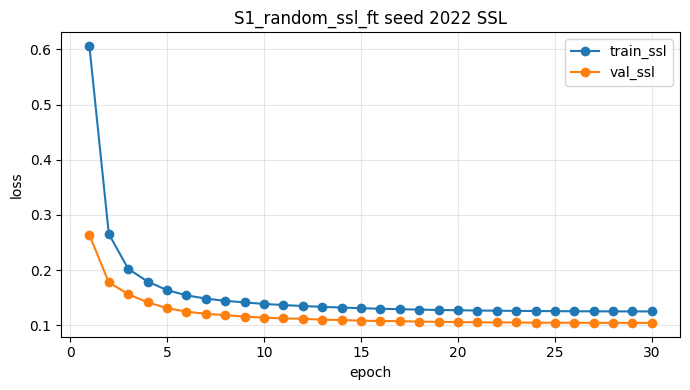

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S1_random_ssl_ft_seed2022_ssl_curve.png
S1_random_ssl_ft seed 2022 FT parameters: 1,118,048
Linear probe: freeze encoder, train forecasting head only.


LP epoch 1/10:   0%|          | 0/556 [00:00<?, ?it/s]

LP epoch 1/10 | train MSE: 0.275627 | val MSE: 0.130559


LP epoch 2/10:   0%|          | 0/556 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c79b83f420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():    
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c79b83f420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

LP epoch 8/10 | train MSE: 0.162289 | val MSE: 0.123376


LP epoch 9/10:   0%|          | 0/556 [00:00<?, ?it/s]

LP epoch 9/10 | train MSE: 0.159650 | val MSE: 0.121371


LP epoch 10/10:   0%|          | 0/556 [00:00<?, ?it/s]

LP epoch 10/10 | train MSE: 0.158069 | val MSE: 0.120332
Best LP val MSE: 0.12033211556823531
S1_random_ssl_ft seed 2022 Linear probe Test MSE: 0.142849
S1_random_ssl_ft seed 2022 Linear probe Test MAE: 0.242048
Recorded result: ('S1_random_ssl_ft', 2022, 'linear_probe')
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.json
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.csv


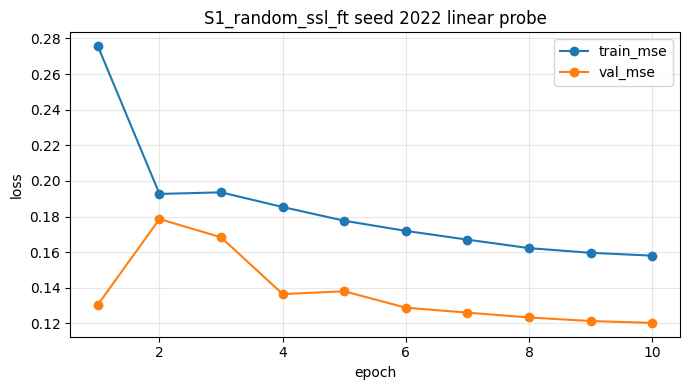

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S1_random_ssl_ft_seed2022_linear_probe_curve.png
Fine-tuning: unfreeze encoder and train all forecasting parameters.


FT epoch 1/10:   0%|          | 0/556 [00:00<?, ?it/s]

FT epoch 1/10 | train MSE: 0.150382 | val MSE: 0.113886


FT epoch 2/10:   0%|          | 0/556 [00:00<?, ?it/s]

FT epoch 2/10 | train MSE: 0.136081 | val MSE: 0.108995


...

FT epoch 8/10 | train MSE: 0.123291 | val MSE: 0.104442


FT epoch 9/10:   0%|          | 0/556 [00:00<?, ?it/s]

FT epoch 9/10 | train MSE: 0.122935 | val MSE: 0.104132


FT epoch 10/10:   0%|          | 0/556 [00:00<?, ?it/s]

FT epoch 10/10 | train MSE: 0.122467 | val MSE: 0.104049
Best FT val MSE: 0.1040487208633263
S1_random_ssl_ft seed 2022 SSL + fine-tuning Test MSE: 0.123786
S1_random_ssl_ft seed 2022 SSL + fine-tuning Test MAE: 0.216924


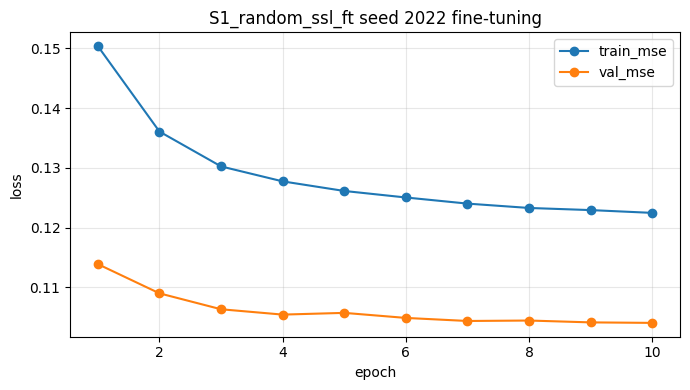

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S1_random_ssl_ft_seed2022_finetune_curve.png
saved checkpoint: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/models/S1_random_ssl_ft_seed2022.pt
Recorded result: ('S1_random_ssl_ft', 2022, 'final')
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.json
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.csv


NameError: name 's1_runs' is not defined

In [13]:
s1_runs[2022] = run_ssl_ft_experiment(S1_CONFIG, seed=2022)

## 3.5) S2 — Harder block-mask SSL + LP + FT

**Goal:** test the variant hypothesis: a harder contiguous-block masking objective may produce better downstream representations than independent random patch masking.

Configuration: same as S1 except the mask is contiguous blocks of 4 patches. With `patch=12`, this masks roughly 48-step spans.


In [16]:
S2_CONFIG = copy.deepcopy(S1_CONFIG)
S2_CONFIG.update({
    "experiment_id": "S2_block_ssl_ft",
    "mask_type": "block",
    "block_size": 4,
})




\n================================================================================
Running S2 seed 2021
Loading existing split from electricity_split.json for L=512, H=96
sizes train=17805 val=2535 test=5167 | num_series=321 num_timesteps=26304
PatchTSTSelfSupervised(
  (encoder): PatchTSTEncoder(
    (tokenizer): NoPadPatchTokenizer()
    (patch_proj): Linear(in_features=12, out_features=128, bias=True)
    (pos_embedding): Embedding(42, 128)
    (layers): ModuleList(
      (0-2): 3 x TSTEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (dropout_attn): Dropout(p=0.2, inplace=False)
        (dropout_ffn): Dropout(p=0.2, inplace=False)
        (norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (norm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (ff): Sequential(
          (0

SSL epoch 1/30:   0%|          | 0/556 [00:00<?, ?it/s]

SSL epoch 1/30 | train SSL loss: 0.602488 | val SSL loss: 0.252048


SSL epoch 2/30:   0%|          | 0/556 [00:00<?, ?it/s]

SSL epoch 2/30 | train SSL loss: 0.269313 | val SSL loss: 0.185992


...

SSL epoch 28/30 | train SSL loss: 0.142274 | val SSL loss: 0.117926


SSL epoch 29/30:   0%|          | 0/556 [00:00<?, ?it/s]

SSL epoch 29/30 | train SSL loss: 0.142281 | val SSL loss: 0.117899


SSL epoch 30/30:   0%|          | 0/556 [00:00<?, ?it/s]

SSL epoch 30/30 | train SSL loss: 0.142257 | val SSL loss: 0.117919
Best SSL val loss: 0.11789871652333224


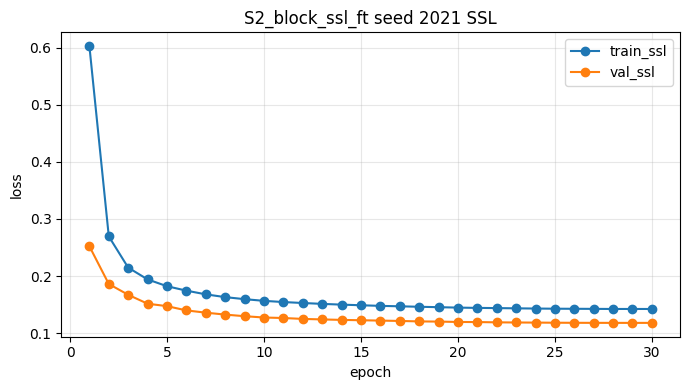

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S2_block_ssl_ft_seed2021_ssl_curve.png
S2_block_ssl_ft seed 2021 FT parameters: 1,118,048
Linear probe: freeze encoder, train forecasting head only.


LP epoch 1/10:   0%|          | 0/556 [00:00<?, ?it/s]

LP epoch 1/10 | train MSE: 0.276025 | val MSE: 0.128177


LP epoch 2/10:   0%|          | 0/556 [00:00<?, ?it/s]

LP epoch 2/10 | train MSE: 0.191691 | val MSE: 0.156872


...

LP epoch 4/10 | train MSE: 0.185684 | val MSE: 0.135611


LP epoch 5/10:   0%|          | 0/556 [00:00<?, ?it/s]

LP epoch 5/10 | train MSE: 0.176688 | val MSE: 0.143579


LP epoch 6/10:   0%|          | 0/556 [00:00<?, ?it/s]

LP epoch 6/10 | train MSE: 0.171933 | val MSE: 0.136501
LP early stopping at epoch 6
Best LP val MSE: 0.12817742538581467
S2_block_ssl_ft seed 2021 Linear probe Test MSE: 0.152932
S2_block_ssl_ft seed 2021 Linear probe Test MAE: 0.258678
Recorded result: ('S2_block_ssl_ft', 2021, 'linear_probe')
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.json
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.csv


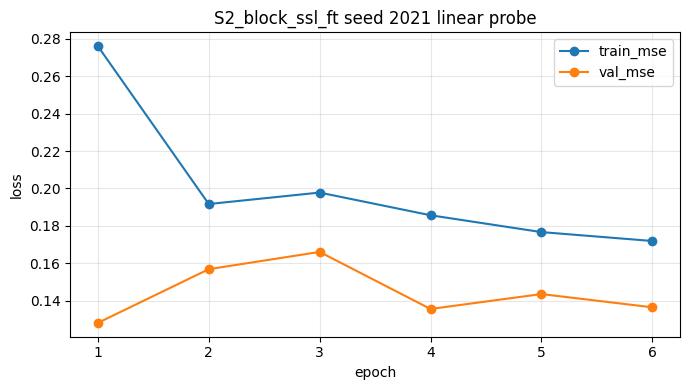

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S2_block_ssl_ft_seed2021_linear_probe_curve.png
Fine-tuning: unfreeze encoder and train all forecasting parameters.


FT epoch 1/10:   0%|          | 0/556 [00:00<?, ?it/s]

FT epoch 1/10 | train MSE: 0.157584 | val MSE: 0.112391


FT epoch 2/10:   0%|          | 0/556 [00:00<?, ?it/s]

FT epoch 2/10 | train MSE: 0.135230 | val MSE: 0.108081


...

FT epoch 8/10 | train MSE: 0.122429 | val MSE: 0.104735


FT epoch 9/10:   0%|          | 0/556 [00:00<?, ?it/s]

FT epoch 9/10 | train MSE: 0.121988 | val MSE: 0.104707


FT epoch 10/10:   0%|          | 0/556 [00:00<?, ?it/s]

FT epoch 10/10 | train MSE: 0.122012 | val MSE: 0.104317
Best FT val MSE: 0.10431691859306903
S2_block_ssl_ft seed 2021 SSL + fine-tuning Test MSE: 0.123595
S2_block_ssl_ft seed 2021 SSL + fine-tuning Test MAE: 0.216225


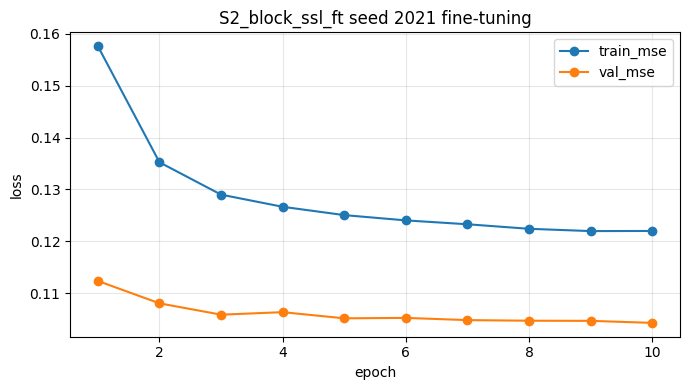

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S2_block_ssl_ft_seed2021_finetune_curve.png
saved checkpoint: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/models/S2_block_ssl_ft_seed2021.pt
Recorded result: ('S2_block_ssl_ft', 2021, 'final')
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.json
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.csv
\n================================================================================
Running S2 seed 2022
Loading existing split from electricity_split.json for L=512, H=96
sizes train=17805 val=2535 test=5167 | num_series=321 num_timesteps=26304
PatchTSTSelfSupervised(
  (encoder): PatchTSTEncoder(
    (tokenizer): NoPadPatchTokenizer()
    (patch_proj): Linear(in_features=12, out_features=128, bias=True)
    (pos_embedding): Embedding(42, 128)
    (layers): ModuleList(
      (0-2): 3 x TSTEncoderLayer(
        (self_at

SSL epoch 1/30:   0%|          | 0/556 [00:00<?, ?it/s]

SSL epoch 1/30 | train SSL loss: 0.598127 | val SSL loss: 0.253454


SSL epoch 2/30:   0%|          | 0/556 [00:00<?, ?it/s]

SSL epoch 2/30 | train SSL loss: 0.265126 | val SSL loss: 0.182635


...

SSL epoch 28/30 | train SSL loss: 0.141985 | val SSL loss: 0.117751


SSL epoch 29/30:   0%|          | 0/556 [00:00<?, ?it/s]

SSL epoch 29/30 | train SSL loss: 0.141933 | val SSL loss: 0.117757


SSL epoch 30/30:   0%|          | 0/556 [00:00<?, ?it/s]

SSL epoch 30/30 | train SSL loss: 0.141951 | val SSL loss: 0.117700
Best SSL val loss: 0.11769965029150777


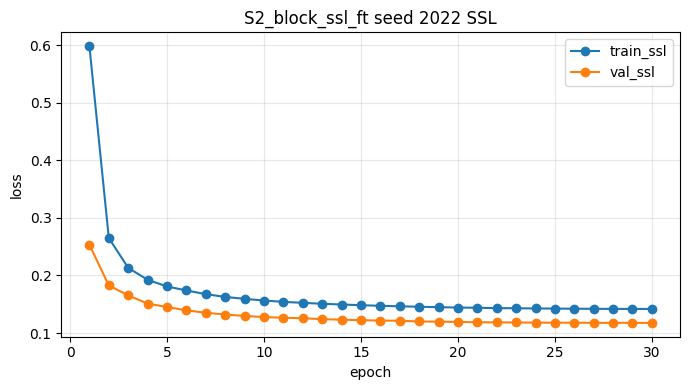

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S2_block_ssl_ft_seed2022_ssl_curve.png
S2_block_ssl_ft seed 2022 FT parameters: 1,118,048
Linear probe: freeze encoder, train forecasting head only.


LP epoch 1/10:   0%|          | 0/556 [00:00<?, ?it/s]

LP epoch 1/10 | train MSE: 0.276460 | val MSE: 0.131111


LP epoch 2/10:   0%|          | 0/556 [00:00<?, ?it/s]

LP epoch 2/10 | train MSE: 0.191874 | val MSE: 0.155518


...

LP epoch 8/10 | train MSE: 0.161798 | val MSE: 0.122110


LP epoch 9/10:   0%|          | 0/556 [00:00<?, ?it/s]

LP epoch 9/10 | train MSE: 0.158952 | val MSE: 0.120833


LP epoch 10/10:   0%|          | 0/556 [00:00<?, ?it/s]

LP epoch 10/10 | train MSE: 0.157417 | val MSE: 0.119956
Best LP val MSE: 0.11995613336327983
S2_block_ssl_ft seed 2022 Linear probe Test MSE: 0.142036
S2_block_ssl_ft seed 2022 Linear probe Test MAE: 0.241291
Recorded result: ('S2_block_ssl_ft', 2022, 'linear_probe')
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.json
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.csv


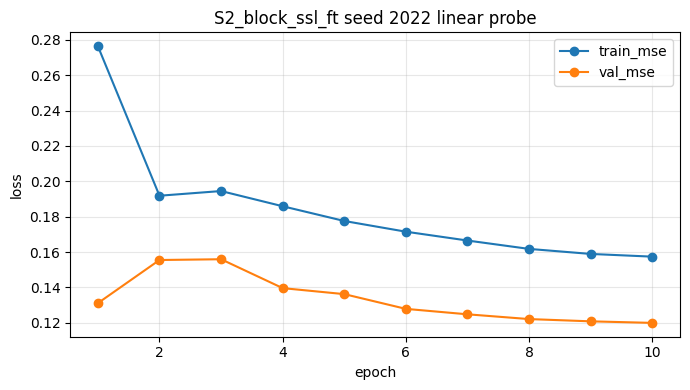

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S2_block_ssl_ft_seed2022_linear_probe_curve.png
Fine-tuning: unfreeze encoder and train all forecasting parameters.


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c79b83f420>
Traceback (most recent call last):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c79b83f420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    self._shutdown_workers()if w.is_alive():

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():  
          ^ ^ ^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'
  File "/usr/lib/python3

FT epoch 1/10:   0%|          | 0/556 [00:00<?, ?it/s]

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError^: can only test a child process
^^^^
: AssertionErrorcan only test a child process


FT epoch 1/10 | train MSE: 0.149626 | val MSE: 0.112949


...

FT epoch 8/10 | train MSE: 0.122621 | val MSE: 0.104718


FT epoch 9/10:   0%|          | 0/556 [00:00<?, ?it/s]

FT epoch 9/10 | train MSE: 0.122296 | val MSE: 0.104459


FT epoch 10/10:   0%|          | 0/556 [00:00<?, ?it/s]

FT epoch 10/10 | train MSE: 0.121793 | val MSE: 0.104426
Best FT val MSE: 0.10442557424835905
S2_block_ssl_ft seed 2022 SSL + fine-tuning Test MSE: 0.123715
S2_block_ssl_ft seed 2022 SSL + fine-tuning Test MAE: 0.216711


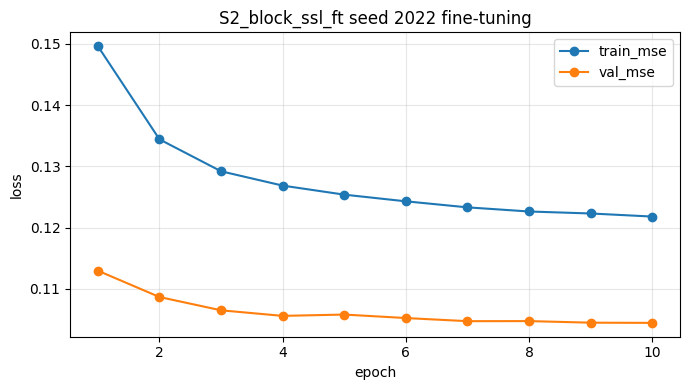

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S2_block_ssl_ft_seed2022_finetune_curve.png
saved checkpoint: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/models/S2_block_ssl_ft_seed2022.pt
Recorded result: ('S2_block_ssl_ft', 2022, 'final')
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.json
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.csv


In [17]:
if RUN_S2:
    s2_runs = {}
    for seed in CORE_SEEDS:
        print("\\n" + "=" * 80)
        print(f"Running S2 seed {seed}")
        print("=" * 80)
        s2_runs[seed] = run_ssl_ft_experiment(S2_CONFIG, seed=seed)
else:
    print("RUN_S2 is False; skipping.")

## 3.6) S3 — Optional overlapping SSL control

**Goal:** diagnostic negative/control experiment. This is **not** the paper-style SSL setup. It intentionally reuses the overlapping supervised patch geometry (`L=336`, `patch=16`, `stride=8`, end padding) to test whether overlapping masked reconstruction gives suspiciously low SSL loss without a clear downstream benefit.

Run this only after B2/S1/S2 are complete.


\n================================================================================
Running S3 seed 2021
Loading existing split from electricity_split.json for L=336, H=96
sizes train=17981 val=2535 test=5167 | num_series=321 num_timesteps=26304
PatchTSTSelfSupervised(
  (encoder): PatchTSTEncoder(
    (tokenizer): EndPadPatchTokenizer()
    (patch_proj): Linear(in_features=16, out_features=128, bias=True)
    (pos_embedding): Embedding(42, 128)
    (layers): ModuleList(
      (0-2): 3 x TSTEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (dropout_attn): Dropout(p=0.2, inplace=False)
        (dropout_ffn): Dropout(p=0.2, inplace=False)
        (norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (norm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (ff): Sequential(
          (

SSL epoch 1/30:   0%|          | 0/561 [00:00<?, ?it/s]

SSL epoch 1/30 | train SSL loss: 0.651255 | val SSL loss: 0.255936


SSL epoch 2/30:   0%|          | 0/561 [00:00<?, ?it/s]

SSL epoch 2/30 | train SSL loss: 0.260632 | val SSL loss: 0.147262


...

SSL epoch 28/30 | train SSL loss: 0.074669 | val SSL loss: 0.043910


SSL epoch 29/30:   0%|          | 0/561 [00:00<?, ?it/s]

SSL epoch 29/30 | train SSL loss: 0.074579 | val SSL loss: 0.043891


SSL epoch 30/30:   0%|          | 0/561 [00:00<?, ?it/s]

SSL epoch 30/30 | train SSL loss: 0.074534 | val SSL loss: 0.043833
Best SSL val loss: 0.04383290519816636


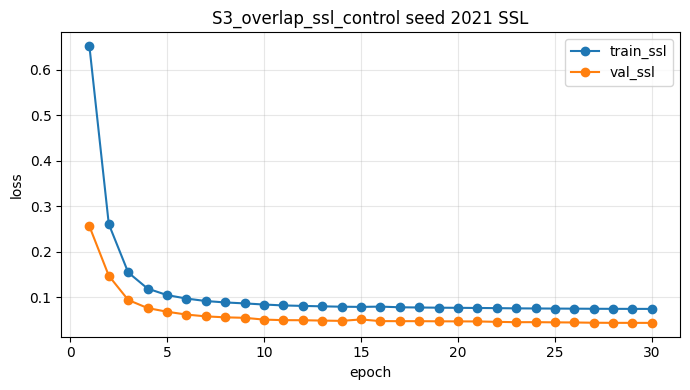

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S3_overlap_ssl_control_seed2021_ssl_curve.png
S3_overlap_ssl_control seed 2021 FT parameters: 921,184
Fine-tuning: unfreeze encoder and train all forecasting parameters.


FT epoch 1/15:   0%|          | 0/561 [00:00<?, ?it/s]

FT epoch 1/15 | train MSE: 0.383969 | val MSE: 0.146269


FT epoch 2/15:   0%|          | 0/561 [00:00<?, ?it/s]

FT epoch 2/15 | train MSE: 0.173624 | val MSE: 0.126948


...

FT epoch 13/15 | train MSE: 0.129055 | val MSE: 0.110838


FT epoch 14/15:   0%|          | 0/561 [00:00<?, ?it/s]

FT epoch 14/15 | train MSE: 0.128920 | val MSE: 0.110602


FT epoch 15/15:   0%|          | 0/561 [00:00<?, ?it/s]

FT epoch 15/15 | train MSE: 0.128857 | val MSE: 0.110646
Best FT val MSE: 0.11060221526455832
S3_overlap_ssl_control seed 2021 SSL + fine-tuning Test MSE: 0.128609
S3_overlap_ssl_control seed 2021 SSL + fine-tuning Test MAE: 0.221695


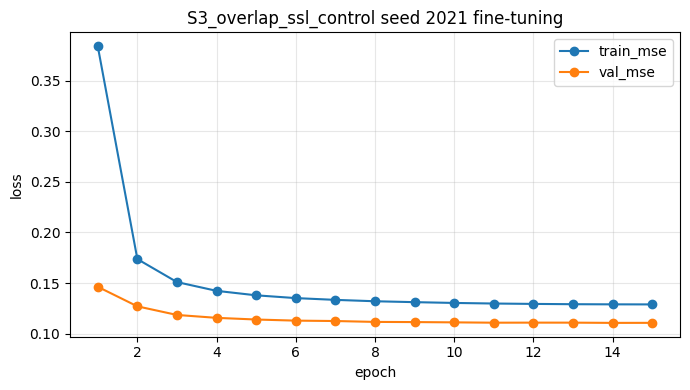

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S3_overlap_ssl_control_seed2021_finetune_curve.png
saved checkpoint: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/models/S3_overlap_ssl_control_seed2021.pt
Recorded result: ('S3_overlap_ssl_control', 2021, 'final')
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.json
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.csv
\n================================================================================
Running S3 seed 2022
Loading existing split from electricity_split.json for L=336, H=96
sizes train=17981 val=2535 test=5167 | num_series=321 num_timesteps=26304
PatchTSTSelfSupervised(
  (encoder): PatchTSTEncoder(
    (tokenizer): EndPadPatchTokenizer()
    (patch_proj): Linear(in_features=16, out_features=128, bias=True)
    (pos_embedding): Embedding(42, 128)
    (layers): ModuleList(
      (0-2): 3 x TSTEncoderL

SSL epoch 1/30:   0%|          | 0/561 [00:00<?, ?it/s]

SSL epoch 1/30 | train SSL loss: 0.636884 | val SSL loss: 0.256548


SSL epoch 2/30:   0%|          | 0/561 [00:00<?, ?it/s]

SSL epoch 2/30 | train SSL loss: 0.263205 | val SSL loss: 0.153266


...

SSL epoch 28/30 | train SSL loss: 0.074907 | val SSL loss: 0.044503


SSL epoch 29/30:   0%|          | 0/561 [00:00<?, ?it/s]

SSL epoch 29/30 | train SSL loss: 0.074877 | val SSL loss: 0.044536


SSL epoch 30/30:   0%|          | 0/561 [00:00<?, ?it/s]

SSL epoch 30/30 | train SSL loss: 0.074842 | val SSL loss: 0.044520
Best SSL val loss: 0.044502653285890405


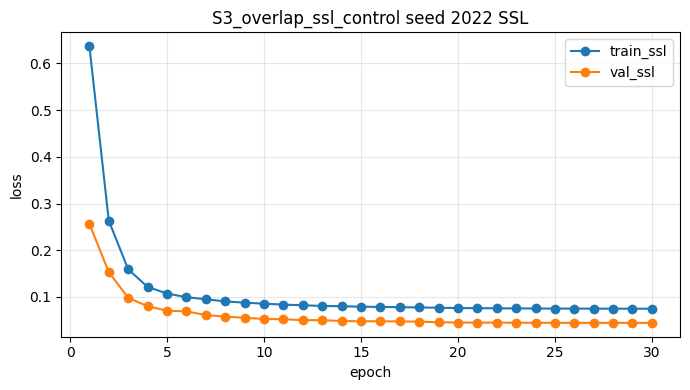

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S3_overlap_ssl_control_seed2022_ssl_curve.png
S3_overlap_ssl_control seed 2022 FT parameters: 921,184
Fine-tuning: unfreeze encoder and train all forecasting parameters.


FT epoch 1/15:   0%|          | 0/561 [00:00<?, ?it/s]

FT epoch 1/15 | train MSE: 0.389366 | val MSE: 0.146931


FT epoch 2/15:   0%|          | 0/561 [00:00<?, ?it/s]

FT epoch 2/15 | train MSE: 0.172894 | val MSE: 0.124929


...

FT epoch 13/15 | train MSE: 0.128586 | val MSE: 0.110798


FT epoch 14/15:   0%|          | 0/561 [00:00<?, ?it/s]

FT epoch 14/15 | train MSE: 0.128503 | val MSE: 0.110726


FT epoch 15/15:   0%|          | 0/561 [00:00<?, ?it/s]

FT epoch 15/15 | train MSE: 0.128372 | val MSE: 0.110642
Best FT val MSE: 0.11064194459945728
S3_overlap_ssl_control seed 2022 SSL + fine-tuning Test MSE: 0.128113
S3_overlap_ssl_control seed 2022 SSL + fine-tuning Test MAE: 0.221357


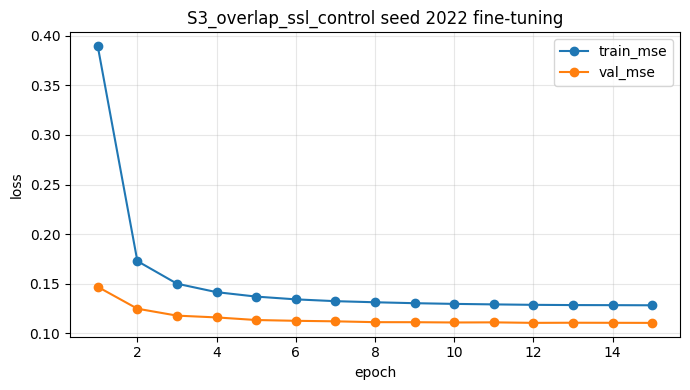

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S3_overlap_ssl_control_seed2022_finetune_curve.png
saved checkpoint: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/models/S3_overlap_ssl_control_seed2022.pt
Recorded result: ('S3_overlap_ssl_control', 2022, 'final')
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.json
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.csv


In [18]:
S3_CONFIG = copy.deepcopy(S1_CONFIG)
S3_CONFIG.update({
    "experiment_id": "S3_overlap_ssl_control",
    "lookback": 336,
    "patch_size": 16,
    "stride": 8,
    "tokenizer": "endpad",
    "d_ff": 256,
    "mask_type": "random",
    "block_size": None,

    "run_linear_probe": False,
})

RUN_S3 = True

if RUN_S3:
    s3_runs = {}
    for seed in CORE_SEEDS:
        print("\\n" + "=" * 80)
        print(f"Running S3 seed {seed}")
        print("=" * 80)
        s3_runs[seed] = run_ssl_ft_experiment(S3_CONFIG, seed=seed)
else:
    print("RUN_S3 is False; skipping.")


## 4) Aggregate results and final plots


In [14]:
df_results = result_table()


,experiment_id,seed,stage,lookback,patch_size,stride,patches,mask_type,pretrain_epochs,train_epochs,best_val_mse,test_mse,test_mae,timestamp,tokenizer,block_size,best_ssl_val,scale_factors
1,B0_last_value_L512,NaN,final,512,NaN,NaN,NaN,none,0,0,NaN,1.587578,0.945355,2026-04-29T13:26:17,NaN,NaN,NaN,NaN
0,B1_42_supervised,2021.0,final,336,16.0,8.0,42.0,none,0,30,0.114457,0.132602,0.226531,2026-04-29T07:33:41,NaN,NaN,NaN,NaN
2,B1_64_supervised,2021.0,final,512,16.0,8.0,64.0,none,0,30,0.109447,0.129382,0.223328,2026-04-29T21:00:49,NaN,NaN,NaN,NaN
4,S1_random_ssl_ft,2021.0,final,512,12.0,12.0,42.0,random,30,15,0.104004,0.124016,0.216403,2026-04-30T03:50:44,nopad,NaN,0.104143,NaN
3,S1_random_ssl_ft,2021.0,linear_probe,512,12.0,12.0,42.0,random,30,6,NaN,0.154440,0.260288,2026-04-30T01:45:48,nopad,NaN,0.104143,NaN
6,S1_random_ssl_ft,2022.0,final,512,12.0,12.0,42.0,random,30,10,0.104049,0.123786,0.216924,2026-04-30T20:18:54,nopad,NaN,0.104486,NaN
5,S1_random_ssl_ft,2022.0,linear_probe,512,12.0,12.0,42.0,random,30,10,NaN,0.142849,0.242048,2026-04-30T19:02:19,nopad,NaN,0.104486,NaN
8,S2_block_ssl_ft,2021.0,final,512,12.0,12.0,42.0,block,30,10,0.104317,0.123595,0.216225,2026-05-01T01:45:21,nopad,4.0,0.117899,NaN
7,S2_block_ssl_ft,2021.0,linear_probe,512,12.0,12.0,42.0,block,30,6,NaN,0.152932,0.258678,2026-05-01T00:29:18,nopad,4.0,0.117899,NaN
10,S2_block_ssl_ft,2022.0,final,512,12.0,12.0,42.0,block,30,10,0.104426,0.123715,0.216711,2026-05-01T07:19:07,nopad,4.0,0.117700,NaN


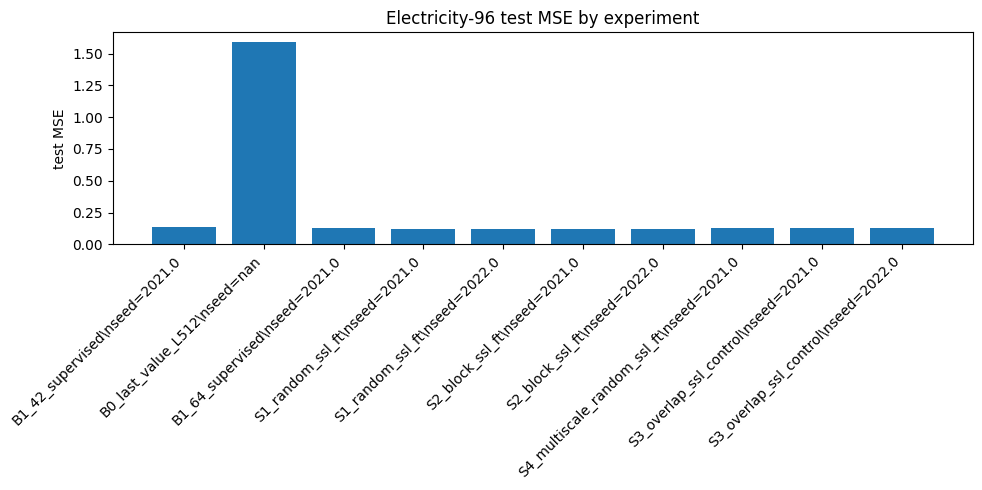

saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/final_test_mse_bar.png


,experiment_id,test_mse_mean,test_mse_std,test_mae_mean,test_mae_std,n
0,S1_random_ssl_ft,0.123901,0.000163,0.216664,0.000369,2
1,S2_block_ssl_ft,0.123655,0.000085,0.216468,0.000343,2


saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/core_seed_summary.csv


In [12]:
if RESULTS:
    df = pd.DataFrame(RESULTS)

    df_final = df[df["stage"] == "final"].copy()
    df_final = df_final.dropna(subset=["test_mse"])

    plt.figure(figsize=(10, 5))
    labels = [
        f"{row['experiment_id']}\\nseed={row['seed']}"
        for _, row in df_final.iterrows()
    ]
    plt.bar(range(len(df_final)), df_final["test_mse"].values)
    plt.xticks(range(len(df_final)), labels, rotation=45, ha="right")
    plt.ylabel("test MSE")
    plt.title("Electricity-96 test MSE by experiment")
    plt.tight_layout()

    bar_path = PLOT_DIR / "final_test_mse_bar.png"
    plt.savefig(bar_path, dpi=160)
    plt.show()
    print("saved:", bar_path)

    core = df_final[df_final["experiment_id"].isin([
        "B2_unified_scratch",
        "S1_random_ssl_ft",
        "S2_block_ssl_ft",
    ])]
    if not core.empty:
        summary = core.groupby("experiment_id").agg(
            test_mse_mean=("test_mse", "mean"),
            test_mse_std=("test_mse", "std"),
            test_mae_mean=("test_mae", "mean"),
            test_mae_std=("test_mae", "std"),
            n=("test_mse", "count"),
        ).reset_index()
        display(summary)
        summary_path = RESULT_DIR / "core_seed_summary.csv"
        summary.to_csv(summary_path, index=False)
        print("saved:", summary_path)
else:
    print("No results to summarize yet.")


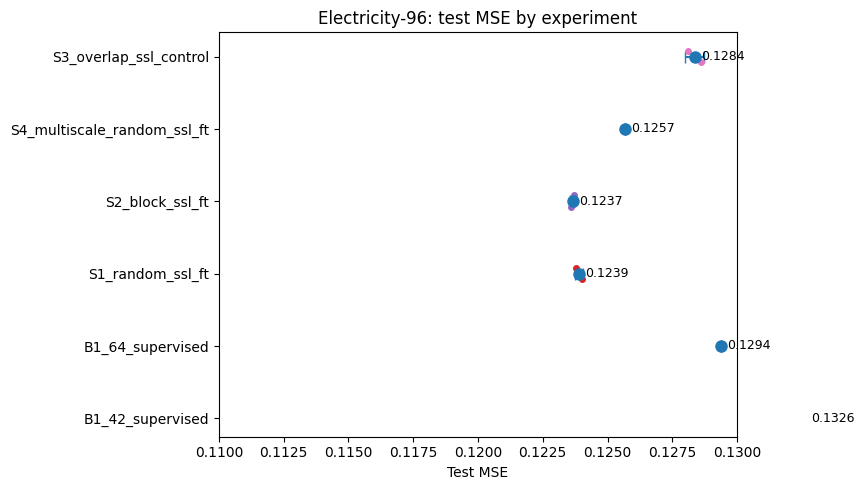

saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/final_test_mse_pointplot_zoom.png


,experiment_id,test_mse_mean,test_mse_std,test_mae_mean,test_mae_std,n
0,S1_random_ssl_ft,0.123901,0.000163,0.216664,0.000369,2
1,S2_block_ssl_ft,0.123655,0.000085,0.216468,0.000343,2


saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/core_seed_summary.csv


In [16]:
if RESULTS:
    df = pd.DataFrame(RESULTS)

    df_final = df[df["stage"] == "final"].copy()
    df_final = df_final.dropna(subset=["test_mse"])

    # Exclude B0 / previous-value baseline from the plot
    df_plot = df_final[
        ~df_final["experiment_id"]
        .astype(str)
        .str.contains("B0|last_value|previous", case=False, regex=True)
    ].copy()

    if not df_plot.empty:
        # Aggregate by experiment_id
        summary = df_plot.groupby("experiment_id", as_index=False).agg(
            test_mse_mean=("test_mse", "mean"),
            test_mse_std=("test_mse", "std"),
            test_mse_min=("test_mse", "min"),
            test_mse_max=("test_mse", "max"),
            n=("test_mse", "count"),
        )

        summary["test_mse_std"] = summary["test_mse_std"].fillna(0.0)

        # Optional: nicer display order
        preferred_order = [
            "B1_42_supervised",
            "B1_64_supervised",
            "S1_random_ssl_ft",
            "S2_block_ssl_ft",
            "S4_multiscale_random_ssl_ft",
            "S3_overlap_ssl_control",
        ]
        present = [x for x in preferred_order if x in summary["experiment_id"].tolist()]
        extra = [x for x in summary["experiment_id"].tolist() if x not in present]
        order = present + extra

        summary["experiment_id"] = pd.Categorical(
            summary["experiment_id"],
            categories=order,
            ordered=True,
        )
        summary = summary.sort_values("experiment_id").reset_index(drop=True)

        # Horizontal point plot
        plt.figure(figsize=(9, 5))
        y = np.arange(len(summary))

        plt.errorbar(
            summary["test_mse_mean"],
            y,
            xerr=summary["test_mse_std"],
            fmt="o",
            capsize=4,
            markersize=8,
        )

        # Overlay individual seed points
        for i, exp_id in enumerate(summary["experiment_id"].astype(str)):
            vals = df_plot.loc[df_plot["experiment_id"] == exp_id, "test_mse"].values
            if len(vals) == 1:
                yy = np.array([i])
            else:
                yy = i + np.linspace(-0.08, 0.08, len(vals))
            plt.plot(vals, yy, marker="o", linestyle="None", markersize=4)

        # Add value labels
        for i, row in summary.iterrows():
            plt.text(
                row["test_mse_mean"] + 0.00025,
                i,
                f"{row['test_mse_mean']:.4f}",
                va="center",
                fontsize=9,
            )

        plt.yticks(y, summary["experiment_id"].astype(str))
        plt.xlabel("Test MSE")
        plt.title("Electricity-96: test MSE by experiment")

        # Zoom into the interesting range
        plt.xlim(0.11, 0.13)

        plt.tight_layout()

        point_path = PLOT_DIR / "final_test_mse_pointplot_zoom.png"
        plt.savefig(point_path, dpi=180)
        plt.show()
        print("saved:", point_path)

    else:
        print("No non-B0 final results to plot.")

    # Keep your summary table
    core = df_final[df_final["experiment_id"].isin([
        "B2_unified_scratch",
        "S1_random_ssl_ft",
        "S2_block_ssl_ft",
    ])]

    if not core.empty:
        core_summary = core.groupby("experiment_id").agg(
            test_mse_mean=("test_mse", "mean"),
            test_mse_std=("test_mse", "std"),
            test_mae_mean=("test_mae", "mean"),
            test_mae_std=("test_mae", "std"),
            n=("test_mse", "count"),
        ).reset_index()
        display(core_summary)

        summary_path = RESULT_DIR / "core_seed_summary.csv"
        core_summary.to_csv(summary_path, index=False)
        print("saved:", summary_path)

else:
    print("No results to summarize yet.")

Available columns:
['experiment_id', 'seed', 'stage', 'lookback', 'patch_size', 'stride', 'patches', 'mask_type', 'pretrain_epochs', 'train_epochs', 'best_val_mse', 'test_mse', 'test_mae', 'timestamp', 'tokenizer', 'block_size', 'best_ssl_val', 'scale_factors']

Preview:


,experiment_id,seed,stage,lookback,patch_size,stride,patches,mask_type,pretrain_epochs,train_epochs,best_val_mse,test_mse,test_mae,timestamp,tokenizer,block_size,best_ssl_val,scale_factors
0,B1_42_supervised,2021.0,final,336,16.0,8.0,42.0,none,0,30,0.114457,0.132602,0.226531,2026-04-29T07:33:41,NaN,NaN,NaN,NaN
1,B0_last_value_L512,NaN,final,512,NaN,NaN,NaN,none,0,0,NaN,1.587578,0.945355,2026-04-29T13:26:17,NaN,NaN,NaN,NaN
2,B1_64_supervised,2021.0,final,512,16.0,8.0,64.0,none,0,30,0.109447,0.129382,0.223328,2026-04-29T21:00:49,NaN,NaN,NaN,NaN
3,S1_random_ssl_ft,2021.0,linear_probe,512,12.0,12.0,42.0,random,30,6,NaN,0.154440,0.260288,2026-04-30T01:45:48,nopad,NaN,0.104143,NaN
4,S1_random_ssl_ft,2021.0,final,512,12.0,12.0,42.0,random,30,15,0.104004,0.124016,0.216403,2026-04-30T03:50:44,nopad,NaN,0.104143,NaN



Using method column: experiment_id
Using MSE column:    test_mse
Using MAE column:    test_mae
Using seed column:   seed
Using stage column:  stage

Aggregated summary:


,method_pretty,mse_mean,mse_std,mse_min,mse_max,n,mae_mean,mae_std
0,Previous value,1.587578,0.000000,1.587578,1.587578,1,0.945355,0.000000
1,PatchTST/42,0.132602,0.000000,0.132602,0.132602,1,0.226531,0.000000
2,PatchTST/64,0.129382,0.000000,0.129382,0.129382,1,0.223328,0.000000
3,"S1 random SSL, linear probe",0.151113,0.007202,0.142849,0.156049,3,0.255257,0.011546
4,S1 random SSL + FT,0.124493,0.001032,0.123786,0.125678,3,0.217575,0.001599
5,"S2 block SSL, linear probe",0.147484,0.007705,0.142036,0.152932,2,0.249985,0.012294
6,S2 block SSL + FT,0.123655,0.000085,0.123595,0.123715,2,0.216468,0.000343
7,S3 overlap SSL + FT,0.128361,0.000351,0.128113,0.128609,2,0.221526,0.000239


Figures will be saved to: /content/drive/MyDrive/5782/PatchTST/figures


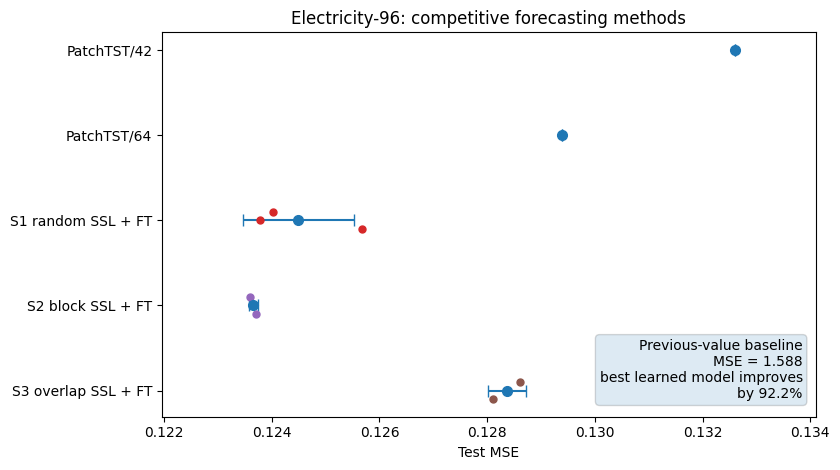

Saved: figures/clean_competitive_test_mse.png


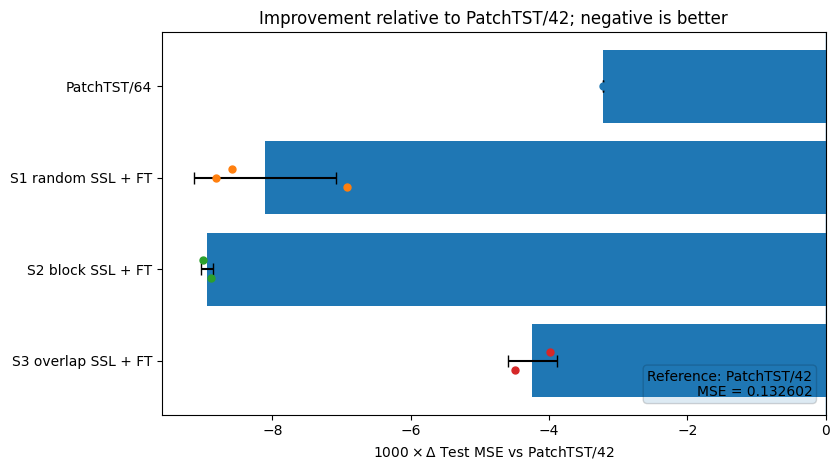

Saved: figures/delta_mse_x1000_vs_patchtst42.png


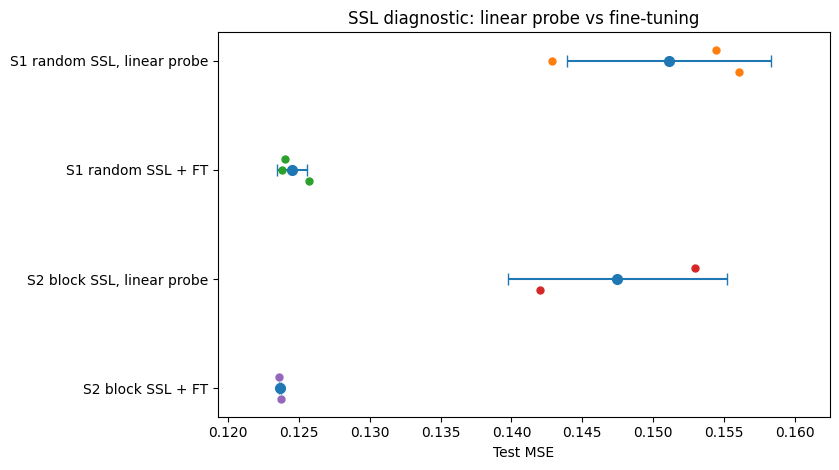

Saved: figures/ssl_lp_vs_ft_diagnostic.png


In [13]:
# ============================================================
# Cleaner final-result plots for poster
# Requires:
#     df_results = result_table()
#
# Produces:
#   1. Clean competitive Test MSE plot, excluding previous-value baseline
#   2. Delta MSE plot relative to PatchTST/42, scaled by 1000
#   3. Optional SSL LP vs FT diagnostic plot
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# -----------------------------
# 0. Basic setup
# -----------------------------
df_plot = df_results.copy()

print("Available columns:")
print(list(df_plot.columns))
print("\nPreview:")
display(df_plot.head())


# -----------------------------
# 1. Robust column detection
# -----------------------------
def find_col(df, preferred_names, must_contain=None, avoid_contains=None, required=True):
    cols = list(df.columns)
    lower_map = {c.lower(): c for c in cols}

    for name in preferred_names:
        if name.lower() in lower_map:
            return lower_map[name.lower()]

    if must_contain is not None:
        if isinstance(must_contain, str):
            must_contain = [must_contain]
        if avoid_contains is None:
            avoid_contains = []
        if isinstance(avoid_contains, str):
            avoid_contains = [avoid_contains]

        candidates = []
        for c in cols:
            cl = c.lower()
            if all(s.lower() in cl for s in must_contain) and not any(
                a.lower() in cl for a in avoid_contains
            ):
                candidates.append(c)

        if candidates:
            return candidates[0]

    if required:
        raise ValueError(
            f"Could not find required column. "
            f"preferred_names={preferred_names}, available={cols}"
        )
    return None


method_col = find_col(
    df_plot,
    preferred_names=["method", "method_label", "experiment_id", "experiment", "exp_id", "id", "name"],
)

mse_col = find_col(
    df_plot,
    preferred_names=["test_mse", "mse_test", "mse", "Test MSE"],
    must_contain=["mse"],
    avoid_contains=["train", "val", "ssl", "best"],
)

mae_col = find_col(
    df_plot,
    preferred_names=["test_mae", "mae_test", "mae", "Test MAE"],
    must_contain=["mae"],
    avoid_contains=["train", "val", "ssl", "best"],
    required=False,
)

seed_col = find_col(
    df_plot,
    preferred_names=["seed", "random_seed"],
    must_contain=["seed"],
    required=False,
)

stage_col = find_col(
    df_plot,
    preferred_names=["stage", "phase", "eval_stage"],
    required=False,
)

print(f"\nUsing method column: {method_col}")
print(f"Using MSE column:    {mse_col}")
print(f"Using MAE column:    {mae_col}")
print(f"Using seed column:   {seed_col}")
print(f"Using stage column:  {stage_col}")


# -----------------------------
# 2. Clean method names
# -----------------------------
df_plot = df_plot.dropna(subset=[mse_col]).copy()
df_plot[mse_col] = pd.to_numeric(df_plot[mse_col], errors="coerce")
df_plot = df_plot.dropna(subset=[mse_col]).copy()

if mae_col is not None:
    df_plot[mae_col] = pd.to_numeric(df_plot[mae_col], errors="coerce")


def pretty_method_name(row):
    raw = str(row[method_col])
    s = raw.lower()

    stage = ""
    if stage_col is not None:
        stage = str(row.get(stage_col, "")).lower()

    # Naive / previous-value baseline
    if (
        "b0" in s
        or "previous" in s
        or "prev" in s
        or "last" in s
        or "naive" in s
        or ("value" in s and "baseline" in s)
    ):
        return "Previous value"

    # Supervised
    if "b1_42" in s or "42_supervised" in s or "patchtst/42" in s:
        return "PatchTST/42"

    if "b1_64" in s or "64_supervised" in s or "patchtst/64" in s:
        return "PatchTST/64"

    # Scratch SSL-backbone
    if "b2" in s or "scratch" in s:
        return "Scratch SSL-backbone"

    # S1 random SSL
    if "s1" in s or ("random" in s and "ssl" in s):
        if "linear" in s or "probe" in s or "lp" in s or "linear" in stage or "probe" in stage:
            return "S1 random SSL, linear probe"
        return "S1 random SSL + FT"

    # S2 block SSL
    if "s2" in s or "block" in s or "hard" in s:
        if "linear" in s or "probe" in s or "lp" in s or "linear" in stage or "probe" in stage:
            return "S2 block SSL, linear probe"
        return "S2 block SSL + FT"

    # S3 overlap control
    if "s3" in s or "overlap" in s:
        if "linear" in s or "probe" in s or "lp" in s or "linear" in stage or "probe" in stage:
            return "S3 overlap SSL, linear probe"
        return "S3 overlap SSL + FT"

    return raw


df_plot["method_pretty"] = df_plot.apply(pretty_method_name, axis=1)


# -----------------------------
# 3. Aggregate over seeds/runs
# -----------------------------
agg_dict = {
    "mse_mean": (mse_col, "mean"),
    "mse_std": (mse_col, "std"),
    "mse_min": (mse_col, "min"),
    "mse_max": (mse_col, "max"),
    "n": (mse_col, "count"),
}

if mae_col is not None:
    agg_dict.update({
        "mae_mean": (mae_col, "mean"),
        "mae_std": (mae_col, "std"),
    })

summary = (
    df_plot
    .groupby("method_pretty", as_index=False)
    .agg(**agg_dict)
)

summary["mse_std"] = summary["mse_std"].fillna(0.0)
if mae_col is not None:
    summary["mae_std"] = summary["mae_std"].fillna(0.0)

preferred_order = [
    "Previous value",
    "PatchTST/42",
    "PatchTST/64",
    "Scratch SSL-backbone",
    "S1 random SSL, linear probe",
    "S1 random SSL + FT",
    "S2 block SSL, linear probe",
    "S2 block SSL + FT",
    "S3 overlap SSL, linear probe",
    "S3 overlap SSL + FT",
]

present = [m for m in preferred_order if m in set(summary["method_pretty"])]
extra = [m for m in summary["method_pretty"].tolist() if m not in set(present)]
ordered = present + extra

summary["method_pretty"] = pd.Categorical(summary["method_pretty"], categories=ordered, ordered=True)
summary = summary.sort_values("method_pretty").reset_index(drop=True)

print("\nAggregated summary:")
display(summary)


# -----------------------------
# 4. Figure directory
# -----------------------------
if "FIG_DIR" in globals():
    fig_dir = Path(FIG_DIR)
elif "GLOBAL" in globals() and "result_dir" in GLOBAL:
    fig_dir = Path(GLOBAL["result_dir"]) / "figures"
elif "GLOBAL" in globals() and "output_dir" in GLOBAL:
    fig_dir = Path(GLOBAL["output_dir"]) / "figures"
else:
    fig_dir = Path("figures")

fig_dir.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {fig_dir.resolve()}")


# -----------------------------
# 5. Helper: overlay individual seeds
# -----------------------------
def overlay_seed_points_horizontal(ax, raw_df, methods, metric_col, value_transform=lambda x: x):
    for i, m in enumerate(methods):
        vals = (
            raw_df.loc[raw_df["method_pretty"] == m, metric_col]
            .dropna()
            .astype(float)
            .to_numpy()
        )
        if len(vals) == 0:
            continue

        vals = value_transform(vals)

        if len(vals) == 1:
            y = np.array([i])
        else:
            y = i + np.linspace(-0.10, 0.10, len(vals))

        ax.plot(vals, y, marker="o", linestyle="None", markersize=5)


# ============================================================
# Plot 1: Clean competitive MSE plot
# ============================================================

# Main model comparison excludes previous-value baseline and linear probes.
main_methods = [
    "PatchTST/42",
    "PatchTST/64",
    "Scratch SSL-backbone",
    "S1 random SSL + FT",
    "S2 block SSL + FT",
    "S3 overlap SSL + FT",
]

main_summary = summary[summary["method_pretty"].astype(str).isin(main_methods)].copy()
main_summary = main_summary.sort_values("method_pretty")
main_methods_present = main_summary["method_pretty"].astype(str).tolist()

if len(main_summary) == 0:
    print("No main methods found for clean competitive MSE plot.")
else:
    y = np.arange(len(main_summary))
    means = main_summary["mse_mean"].to_numpy()
    stds = main_summary["mse_std"].to_numpy()

    fig, ax = plt.subplots(figsize=(8.5, 4.8))

    # Horizontal point-range plot
    ax.errorbar(
        means,
        y,
        xerr=stds,
        fmt="o",
        capsize=4,
        markersize=7,
    )

    overlay_seed_points_horizontal(
        ax,
        df_plot,
        main_methods_present,
        mse_col,
        value_transform=lambda x: x,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(main_methods_present)
    ax.invert_yaxis()
    ax.set_xlabel("Test MSE")
    ax.set_title("Electricity-96: competitive forecasting methods")

    # Tight x-axis around competitive methods
    x_min = float(np.nanmin(means - stds))
    x_max = float(np.nanmax(means + stds))
    pad = max(0.0015, 0.12 * (x_max - x_min))
    ax.set_xlim(x_min - pad, x_max + pad)

    # Previous-value baseline as a callout, not a bar
    prev_rows = summary[summary["method_pretty"].astype(str) == "Previous value"]
    if len(prev_rows) > 0:
        prev_mse = float(prev_rows.iloc[0]["mse_mean"])
        best_mse = float(main_summary["mse_mean"].min())
        pct_gain = (prev_mse - best_mse) / prev_mse * 100.0

        text = (
            f"Previous-value baseline\n"
            f"MSE = {prev_mse:.3f}\n"
            f"best learned model improves\n"
            f"by {pct_gain:.1f}%"
        )

        ax.text(
            0.98,
            0.04,
            text,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            bbox=dict(boxstyle="round", alpha=0.15),
        )

    fig.tight_layout()
    path1 = fig_dir / "clean_competitive_test_mse.png"
    fig.savefig(path1, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path1}")


# ============================================================
# Plot 2: Delta MSE relative to PatchTST/42, scaled by 1000
# ============================================================

ref_rows = summary[summary["method_pretty"].astype(str) == "PatchTST/42"]

if len(ref_rows) == 0:
    print("No PatchTST/42 reference found. Skipping delta plot.")
else:
    ref_mse = float(ref_rows.iloc[0]["mse_mean"])

    delta_methods = [
        "PatchTST/64",
        "Scratch SSL-backbone",
        "S1 random SSL + FT",
        "S2 block SSL + FT",
        "S3 overlap SSL + FT",
    ]

    delta_summary = summary[summary["method_pretty"].astype(str).isin(delta_methods)].copy()
    delta_summary = delta_summary.sort_values("method_pretty")

    if len(delta_summary) == 0:
        print("No comparison methods found for delta plot.")
    else:
        delta_summary["delta_x1000"] = 1000.0 * (delta_summary["mse_mean"] - ref_mse)
        delta_summary["delta_std_x1000"] = 1000.0 * delta_summary["mse_std"]

        methods_delta = delta_summary["method_pretty"].astype(str).tolist()
        y = np.arange(len(delta_summary))

        fig, ax = plt.subplots(figsize=(8.5, 4.8))

        ax.axvline(0.0, linewidth=1)
        ax.barh(
            y,
            delta_summary["delta_x1000"].to_numpy(),
            xerr=delta_summary["delta_std_x1000"].to_numpy(),
            capsize=4,
        )

        # Overlay individual run deltas relative to PatchTST/42 mean
        for i, m in enumerate(methods_delta):
            vals = (
                df_plot.loc[df_plot["method_pretty"] == m, mse_col]
                .dropna()
                .astype(float)
                .to_numpy()
            )
            if len(vals) == 0:
                continue

            vals_delta = 1000.0 * (vals - ref_mse)

            if len(vals_delta) == 1:
                yy = np.array([i])
            else:
                yy = i + np.linspace(-0.10, 0.10, len(vals_delta))

            ax.plot(vals_delta, yy, marker="o", linestyle="None", markersize=5)

        ax.set_yticks(y)
        ax.set_yticklabels(methods_delta)
        ax.invert_yaxis()
        ax.set_xlabel(r"$1000 \times \Delta$ Test MSE vs PatchTST/42")
        ax.set_title("Improvement relative to PatchTST/42; negative is better")

        # Add annotation for reference
        ax.text(
            0.98,
            0.04,
            f"Reference: PatchTST/42\nMSE = {ref_mse:.6f}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            bbox=dict(boxstyle="round", alpha=0.15),
        )

        fig.tight_layout()
        path2 = fig_dir / "delta_mse_x1000_vs_patchtst42.png"
        fig.savefig(path2, dpi=220, bbox_inches="tight")
        plt.show()
        print(f"Saved: {path2}")


# ============================================================
# Plot 3: SSL diagnostic, LP vs FT only
# ============================================================

ssl_diag_methods = [
    "S1 random SSL, linear probe",
    "S1 random SSL + FT",
    "S2 block SSL, linear probe",
    "S2 block SSL + FT",
]

ssl_diag = summary[summary["method_pretty"].astype(str).isin(ssl_diag_methods)].copy()
ssl_diag = ssl_diag.sort_values("method_pretty")

if len(ssl_diag) >= 2:
    y = np.arange(len(ssl_diag))
    means = ssl_diag["mse_mean"].to_numpy()
    stds = ssl_diag["mse_std"].to_numpy()
    methods_ssl = ssl_diag["method_pretty"].astype(str).tolist()

    fig, ax = plt.subplots(figsize=(8.5, 4.8))

    ax.errorbar(
        means,
        y,
        xerr=stds,
        fmt="o",
        capsize=4,
        markersize=7,
    )

    overlay_seed_points_horizontal(
        ax,
        df_plot,
        methods_ssl,
        mse_col,
        value_transform=lambda x: x,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(methods_ssl)
    ax.invert_yaxis()
    ax.set_xlabel("Test MSE")
    ax.set_title("SSL diagnostic: linear probe vs fine-tuning")

    x_min = float(np.nanmin(means - stds))
    x_max = float(np.nanmax(means + stds))
    pad = max(0.0015, 0.12 * (x_max - x_min))
    ax.set_xlim(x_min - pad, x_max + pad)

    fig.tight_layout()
    path3 = fig_dir / "ssl_lp_vs_ft_diagnostic.png"
    fig.savefig(path3, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path3}")
else:
    print("Not enough SSL LP/FT rows for diagnostic plot.")

In [14]:
# ============================================================
# S4: Multiscale random-mask SSL + fine-tuning
# Paste this cell AFTER the existing run_ssl_ft_experiment cell.
# It does not modify PatchTSTSelfSupervised or build_ssl_model.
# ============================================================

class MultiScalePatchTSTSelfSupervised(nn.Module):
    """
    Separate SSL model for multiscale masked-patch pretraining.

    This model owns an ordinary PatchTSTSelfSupervised instance internally, but
    before the masked reconstruction forward pass it replaces the input by a
    randomly sampled coarse-grained view.

    Coarse-graining used here:
        x -> AvgPool_1d(factor=f) -> interpolate back to original length L

    The upsampling step keeps the same tokenizer geometry, patch count,
    positional embeddings, and forecasting fine-tuning code as S1.
    """

    def __init__(
        self,
        *,
        scale_factors=(1, 2, 4),
        scale_probs=None,
        eval_factor=1,
        coarse_pad_mode="replicate",
        coarse_interpolation_mode="linear",
        **ssl_kwargs,
    ):
        super().__init__()
        if not scale_factors:
            raise ValueError("scale_factors must be a non-empty tuple/list")

        self.scale_factors = tuple(int(f) for f in scale_factors)
        if any(f <= 0 for f in self.scale_factors):
            raise ValueError(f"all scale_factors must be positive, got {self.scale_factors}")

        self.eval_factor = int(eval_factor)
        if self.eval_factor <= 0:
            raise ValueError("eval_factor must be positive")

        self.coarse_pad_mode = coarse_pad_mode
        self.coarse_interpolation_mode = coarse_interpolation_mode

        if scale_probs is None:
            self.scale_probs = None
        else:
            if len(scale_probs) != len(self.scale_factors):
                raise ValueError("scale_probs must have the same length as scale_factors")
            probs = torch.tensor(scale_probs, dtype=torch.float32)
            probs = probs / probs.sum().clamp_min(1e-12)
            self.register_buffer("scale_probs", probs)

        # This is a separate model instance. The original PatchTSTSelfSupervised
        # class and the existing S1/S2 ssl_model objects are unchanged.
        self.base_ssl = PatchTSTSelfSupervised(**ssl_kwargs)

        # Expose encoder so the existing FixedPatchTSTForecastHead can attach to it.
        self.encoder = self.base_ssl.encoder

    def _sample_factor(self, device):
        if not self.training:
            return self.eval_factor

        if len(self.scale_factors) == 1:
            return self.scale_factors[0]

        if self.scale_probs is None:
            idx = torch.randint(len(self.scale_factors), size=(1,), device=device).item()
        else:
            idx = torch.multinomial(self.scale_probs.to(device), num_samples=1).item()
        return self.scale_factors[idx]

    def _coarse_grain_same_length(self, x: torch.Tensor, factor: int) -> torch.Tensor:
        """
        Args:
            x: (B, C, L)
            factor: positive integer coarse-graining factor
        Returns:
            x_ms: (B, C, L), smoothed/coarse-grained and restored to length L
        """
        if factor == 1:
            return x

        if x.dim() != 3:
            raise ValueError(f"Expected x with shape (B,C,L), got {tuple(x.shape)}")

        length = x.size(-1)
        pad_len = (factor - (length % factor)) % factor
        if pad_len:
            x_pool = F.pad(x, (0, pad_len), mode=self.coarse_pad_mode)
        else:
            x_pool = x

        # Anti-aliasing / local block average, then decimate by factor.
        x_pool = F.avg_pool1d(x_pool, kernel_size=factor, stride=factor)

        # Return to the original grid so the same PatchTST geometry is reused.
        if self.coarse_interpolation_mode == "nearest":
            x_ms = F.interpolate(x_pool, size=length, mode="nearest")
        else:
            x_ms = F.interpolate(
                x_pool,
                size=length,
                mode=self.coarse_interpolation_mode,
                align_corners=False,
            )
        return x_ms

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        # Keep encode behavior standard for compatibility.
        return self.base_ssl.encode(x)

    def forward(self, x: torch.Tensor, patch_mask=None, mask_ratio=None):
        factor = self._sample_factor(x.device)
        x_ms = self._coarse_grain_same_length(x.float(), factor)
        return self.base_ssl(x_ms, patch_mask=patch_mask, mask_ratio=mask_ratio)


def build_multiscale_ssl_model(config: dict):
    """Build S4 multiscale random-mask SSL model without changing build_ssl_model."""
    return MultiScalePatchTSTSelfSupervised(
        scale_factors=config.get("scale_factors", (1, 2, 4)),
        scale_probs=config.get("scale_probs", None),
        eval_factor=config.get("multiscale_eval_factor", 1),
        coarse_pad_mode=config.get("coarse_pad_mode", "replicate"),
        coarse_interpolation_mode=config.get("coarse_interpolation_mode", "linear"),
        lookback_window=config["lookback"],
        patch_size=config["patch_size"],
        stride=config["stride"],
        d_model=config["d_model"],
        n_heads=config["n_heads"],
        n_layers=config["n_layers"],
        d_ff=config["d_ff"],
        dropout=config["dropout"],
        attn_dropout=config["attn_dropout"],
        activation=config.get("activation", "relu"),
        norm_type=config.get("norm_type", "batch"),
        pre_norm=config.get("pre_norm", False),
        tokenizer=config.get("tokenizer", "nopad"),
        mask_ratio=config["mask_ratio"],
    )


def run_multiscale_ssl_ft_experiment(config: dict, seed: int):
    """S4 runner. Same pipeline as run_ssl_ft_experiment, but with S4 model builder."""
    set_seed(seed)
    cleanup_cuda()

    exp_id = config["experiment_id"]
    train_loader, val_loader, test_loader, split_info = make_loaders(
        lookback=config["lookback"],
        horizon=config["horizon"],
        batch_size=config["batch_size"],
    )

    mask_fn = make_mask_fn(
        mask_type=config["mask_type"],
        mask_ratio=config["mask_ratio"],
        block_size=config.get("block_size", 4) or 4,
    )

    ssl_model = build_multiscale_ssl_model(config).to(device)
    print(ssl_model)
    print(f"{exp_id} seed {seed} SSL parameters: {count_parameters(ssl_model):,}")
    print(f"num_patches: {ssl_model.encoder.num_patches}")
    print(f"scale_factors: {ssl_model.scale_factors}; eval_factor: {ssl_model.eval_factor}")

    ssl_history, ssl_best_state, best_ssl_val = pretrain_ssl_onecycle(
        model=ssl_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        max_epochs=config["ssl_epochs"],
        max_lr=config["ssl_max_lr"],
        mask_fn=mask_fn,
        patience=config["ssl_patience"],
        weight_decay=config["weight_decay"],
        grad_clip=config["grad_clip"],
        pct_start=config["pct_start"],
        amp=config["use_amp"],
        desc="S4 multiscale SSL",
    )

    plot_history(
        ssl_history,
        train_key="train_ssl",
        val_key="val_ssl",
        title=f"{exp_id} seed {seed} SSL",
        save_path=PLOT_DIR / f"{exp_id}_seed{seed}_ssl_curve.png",
    )

    forecast_model = FixedPatchTSTForecastHead(
        encoder=ssl_model.encoder,
        horizon=config["horizon"],
        dropout=config["dropout"],
    ).to(device)

    print(f"{exp_id} seed {seed} FT parameters: {count_parameters(forecast_model):,}")

    lp_history = []
    lp_metrics = None
    if config.get("run_linear_probe", True):
        print("Linear probe: freeze encoder, train forecasting head only.")
        set_encoder_trainable(forecast_model, False)

        lp_history, lp_best_state, lp_best_val = train_forecaster_onecycle(
            model=forecast_model,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            max_epochs=config["linear_probe_epochs"],
            max_lr=config["linear_probe_max_lr"],
            patience=config["linear_probe_patience"],
            weight_decay=config["weight_decay"],
            grad_clip=config["grad_clip"],
            pct_start=config["pct_start"],
            amp=config["use_amp"],
            desc="S4 LP",
        )

        lp_metrics = evaluate_forecast(forecast_model, test_loader, device)
        print(f"{exp_id} seed {seed} Linear probe Test MSE: {lp_metrics['mse']:.6f}")
        print(f"{exp_id} seed {seed} Linear probe Test MAE: {lp_metrics['mae']:.6f}")

        record_result({
            "experiment_id": exp_id,
            "seed": seed,
            "stage": "linear_probe",
            "lookback": config["lookback"],
            "patch_size": config["patch_size"],
            "stride": config["stride"],
            "patches": forecast_model.encoder.num_patches,
            "tokenizer": config.get("tokenizer", "nopad"),
            "mask_type": config["mask_type"],
            "block_size": config.get("block_size", None),
            "scale_factors": str(config.get("scale_factors", (1, 2, 4))),
            "pretrain_epochs": len(ssl_history),
            "train_epochs": len(lp_history),
            "best_ssl_val": best_ssl_val,
            "test_mse": lp_metrics["mse"],
            "test_mae": lp_metrics["mae"],
        })

        plot_history(
            lp_history,
            train_key="train_mse",
            val_key="val_mse",
            title=f"{exp_id} seed {seed} linear probe",
            save_path=PLOT_DIR / f"{exp_id}_seed{seed}_linear_probe_curve.png",
        )

    print("Fine-tuning: unfreeze encoder and train all forecasting parameters.")
    set_encoder_trainable(forecast_model, True)

    ft_history, ft_best_state, best_ft_val = train_forecaster_onecycle(
        model=forecast_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        max_epochs=config["finetune_epochs"],
        max_lr=config["finetune_max_lr"],
        patience=config["finetune_patience"],
        weight_decay=config["weight_decay"],
        grad_clip=config["grad_clip"],
        pct_start=config["pct_start"],
        amp=config["use_amp"],
        desc="S4 FT",
    )

    ft_metrics = evaluate_forecast(forecast_model, test_loader, device)
    print(f"{exp_id} seed {seed} SSL + fine-tuning Test MSE: {ft_metrics['mse']:.6f}")
    print(f"{exp_id} seed {seed} SSL + fine-tuning Test MAE: {ft_metrics['mae']:.6f}")

    plot_history(
        ft_history,
        train_key="train_mse",
        val_key="val_mse",
        title=f"{exp_id} seed {seed} fine-tuning",
        save_path=PLOT_DIR / f"{exp_id}_seed{seed}_finetune_curve.png",
    )

    ckpt_path = MODEL_DIR / f"{exp_id}_seed{seed}.pt"
    save_experiment_checkpoint(
        path=ckpt_path,
        model=forecast_model,
        config=config,
        history={
            "ssl": ssl_history,
            "linear_probe": lp_history,
            "finetune": ft_history,
        },
        metrics={
            "best_ssl_val": best_ssl_val,
            "linear_probe_test": lp_metrics,
            "best_ft_val_mse": best_ft_val,
            "finetune_test": ft_metrics,
        },
        extra={
            "ssl_state_dict": clone_state_dict_to_cpu(ssl_model),
            "split_info": split_info,
            "seed": seed,
            "scale_factors": config.get("scale_factors", (1, 2, 4)),
        },
    )
    print("saved checkpoint:", ckpt_path)

    record_result({
        "experiment_id": exp_id,
        "seed": seed,
        "stage": "final",
        "lookback": config["lookback"],
        "patch_size": config["patch_size"],
        "stride": config["stride"],
        "patches": forecast_model.encoder.num_patches,
        "tokenizer": config.get("tokenizer", "nopad"),
        "mask_type": config["mask_type"],
        "block_size": config.get("block_size", None),
        "scale_factors": str(config.get("scale_factors", (1, 2, 4))),
        "pretrain_epochs": len(ssl_history),
        "train_epochs": len(ft_history),
        "best_ssl_val": best_ssl_val,
        "best_val_mse": best_ft_val,
        "test_mse": ft_metrics["mse"],
        "test_mae": ft_metrics["mae"],
    })

    return ssl_model, forecast_model, {
        "ssl_history": ssl_history,
        "lp_history": lp_history,
        "ft_history": ft_history,
        "lp_metrics": lp_metrics,
        "ft_metrics": ft_metrics,
        "best_ssl_val": best_ssl_val,
        "best_ft_val": best_ft_val,
    }



Running S4 multiscale random-mask SSL+FT seed 2021
Loading existing split from electricity_split.json for L=512, H=96
sizes train=17805 val=2535 test=5167 | num_series=321 num_timesteps=26304
MultiScalePatchTSTSelfSupervised(
  (base_ssl): PatchTSTSelfSupervised(
    (encoder): PatchTSTEncoder(
      (tokenizer): NoPadPatchTokenizer()
      (patch_proj): Linear(in_features=12, out_features=128, bias=True)
      (pos_embedding): Embedding(42, 128)
      (layers): ModuleList(
        (0-2): 3 x TSTEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (dropout_attn): Dropout(p=0.2, inplace=False)
          (dropout_ffn): Dropout(p=0.2, inplace=False)
          (norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (norm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (ff): 

S4 multiscale SSL epoch 1/30:   0%|          | 0/556 [00:00<?, ?it/s]

S4 multiscale SSL epoch 1/30 | train SSL loss: 0.599332 | val SSL loss: 0.273099


S4 multiscale SSL epoch 2/30:   0%|          | 0/556 [00:00<?, ?it/s]

S4 multiscale SSL epoch 2/30 | train SSL loss: 0.257359 | val SSL loss: 0.194241


...

S4 multiscale SSL epoch 28/30 | train SSL loss: 0.095305 | val SSL loss: 0.120993


S4 multiscale SSL epoch 29/30:   0%|          | 0/556 [00:00<?, ?it/s]

S4 multiscale SSL epoch 29/30 | train SSL loss: 0.095116 | val SSL loss: 0.117075


S4 multiscale SSL epoch 30/30:   0%|          | 0/556 [00:00<?, ?it/s]

S4 multiscale SSL epoch 30/30 | train SSL loss: 0.093811 | val SSL loss: 0.115299
Best S4 multiscale SSL val loss: 0.11529936505962876


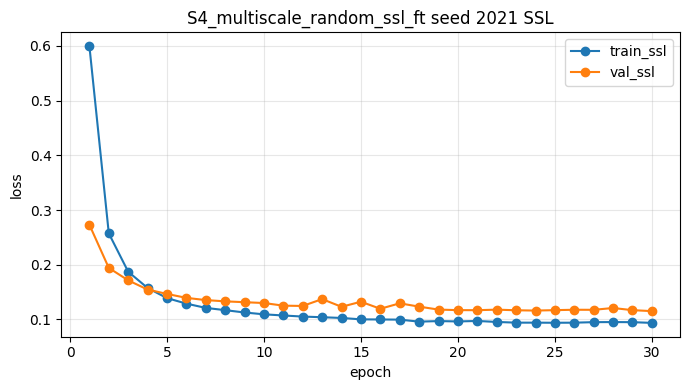

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S4_multiscale_random_ssl_ft_seed2021_ssl_curve.png
S4_multiscale_random_ssl_ft seed 2021 FT parameters: 1,118,048
Fine-tuning: unfreeze encoder and train all forecasting parameters.


S4 FT epoch 1/15:   0%|          | 0/556 [00:00<?, ?it/s]

S4 FT epoch 1/15 | train MSE: 0.419680 | val MSE: 0.146480


S4 FT epoch 2/15:   0%|          | 0/556 [00:00<?, ?it/s]

S4 FT epoch 2/15 | train MSE: 0.175247 | val MSE: 0.121468


...

S4 FT epoch 13/15 | train MSE: 0.126118 | val MSE: 0.106531


S4 FT epoch 14/15:   0%|          | 0/556 [00:00<?, ?it/s]

S4 FT epoch 14/15 | train MSE: 0.125751 | val MSE: 0.106706


S4 FT epoch 15/15:   0%|          | 0/556 [00:00<?, ?it/s]

S4 FT epoch 15/15 | train MSE: 0.125688 | val MSE: 0.106408
Best S4 FT val MSE: 0.10640787976909671
S4_multiscale_random_ssl_ft seed 2021 SSL + fine-tuning Test MSE: 0.125678
S4_multiscale_random_ssl_ft seed 2021 SSL + fine-tuning Test MAE: 0.219397


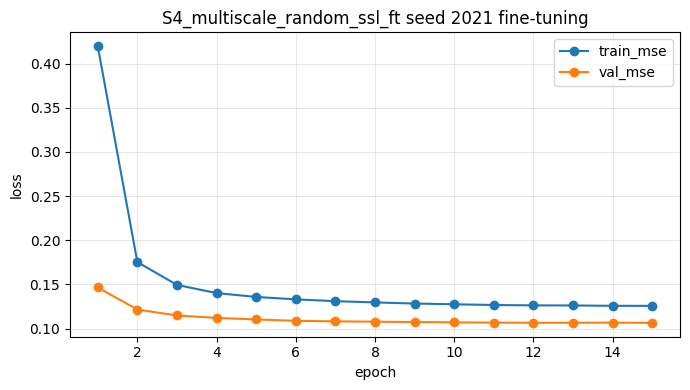

saved plot: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/plots/S4_multiscale_random_ssl_ft_seed2021_finetune_curve.png
saved checkpoint: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/models/S4_multiscale_random_ssl_ft_seed2021.pt
Recorded result: ('S4_multiscale_random_ssl_ft', 2021, 'final')
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.json
Saved: /content/drive/MyDrive/5782/PatchTST/experiment_artifacts/results/experiment_results.csv


In [16]:
# ============================================================
# S4 experiment cell
# Paste this AFTER S1_CONFIG is defined.
# ============================================================

RUN_S4 = True

S4_CONFIG = copy.deepcopy(S1_CONFIG)
S4_CONFIG.update({
    "experiment_id": "S4_multiscale_random_ssl_ft",

    # Keep S1 SSL geometry and random masking.
    "lookback": 512,
    "patch_size": 12,
    "stride": 12,
    "tokenizer": "nopad",
    "mask_type": "random",
    "mask_ratio": 0.4,
    "block_size": None,

    # Multiscale masked SSL settings.
    "scale_factors": (1, 2, 4),
    "scale_probs": None,              # uniform over scales
    "multiscale_eval_factor": 1,      # validation SSL loss uses raw scale for comparability
    "coarse_pad_mode": "replicate",
    "coarse_interpolation_mode": "linear",

    "run_linear_probe": False,

    # Disable FT early stopping.
    "finetune_patience": 999,
})

if RUN_S4:
    s4_runs = {}
    # First run one seed. Add CORE_SEEDS after confirming it runs.
    for seed in [CORE_SEEDS[0]]:
        print("\n" + "=" * 80)
        print(f"Running S4 multiscale random-mask SSL+FT seed {seed}")
        print("=" * 80)
        s4_runs[seed] = run_multiscale_ssl_ft_experiment(S4_CONFIG, seed=seed)
else:
    print("RUN_S4 is False; skipping.")


In [1]:
print("s4_runs exists:", "s4_runs" in globals())

if "s4_runs" in globals():
    print("s4_runs keys:", list(s4_runs.keys()))

    seed = CORE_SEEDS[0]
    if seed in s4_runs:
        print("S4 returned successfully.")
        print("type(s4_runs[seed]):", type(s4_runs[seed]))
        print("length:", len(s4_runs[seed]))

        s4_ssl_model = s4_runs[seed][0]
        s4_forecast_model = s4_runs[seed][1]
        s4_info = s4_runs[seed][2]

        print("s4_ssl_model:", type(s4_ssl_model))
        print("s4_forecast_model:", type(s4_forecast_model))
        print("s4_info keys:", s4_info.keys())
    else:
        print("No completed S4 result stored for seed", seed)
else:
    print("No s4_runs variable found.")

s4_runs exists: False
No s4_runs variable found.


In [ ]:
# ============================================================
# EX1: Supervised PatchTST/64 on exchange_rate.csv
# ============================================================
# Purpose:
#   Add a second-dataset supervised run.
#   This is NOT part of the main Electricity SSL ablation.
#
# Recommended:
#   Use PatchTST/64-style supervised setup:
#       L = 512, patch = 16, stride = 8, 64 patches
#
# Because Exchange has far fewer channels than Electricity, B1-64
# should usually fit at batch_size=32 on a T4/A100.
# ============================================================

from pathlib import Path
from torch.utils.data import DataLoader
import torch


RUN_EXCHANGE_SUPERVISED = True


def find_exchange_csv():
    candidates = [
        PROJECT_DIR / "dataset" / "exchange_rate.csv",
        PROJECT_DIR / "datasets" / "exchange_rate.csv",
        PROJECT_DIR / "exchange_rate.csv",
        Path("dataset/exchange_rate.csv"),
        Path("datasets/exchange_rate.csv"),
        Path("exchange_rate.csv"),
    ]

    for p in candidates:
        p = Path(p)
        if p.exists():
            return p.resolve()

    raise FileNotFoundError(
        "Could not find exchange_rate.csv. "
        "Expected one of: "
        + ", ".join(str(p) for p in candidates)
    )


def make_exchange_loaders(
    data_path,
    split_path,
    lookback,
    horizon,
    batch_size,
    num_workers=0,
):
    """
    Dedicated loader for exchange_rate.csv.

    This avoids accidentally using electricity_split.json or the old
    GLOBAL['data_path'] / GLOBAL['split_path'] defaults.
    """
    data_path = str(Path(data_path))
    split_path = str(Path(split_path))

    if Path(split_path).exists():
        print(f"Loading existing Exchange split from {split_path} for L={lookback}, H={horizon}")
        train_ds, val_ds, test_ds, info = load_splits(
            split_path,
            lookback=lookback,
            horizon=horizon,
        )
    else:
        print(f"Computing new Exchange split and saving to {split_path}")
        train_ds, val_ds, test_ds, info = prepare_splits(
            data_path=data_path,
            lookback=lookback,
            horizon=horizon,
            split_path=split_path,
        )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=GLOBAL["pin_memory"],
        drop_last=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=GLOBAL["pin_memory"],
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=GLOBAL["pin_memory"],
    )

    print(
        f"Exchange sizes train={len(train_ds)} val={len(val_ds)} test={len(test_ds)} | "
        f"num_series={info['num_series']} num_timesteps={info['num_timesteps']} | "
        f"batch_size={batch_size} num_workers={num_workers}"
    )

    return train_loader, val_loader, test_loader, info


def run_exchange_supervised_experiment(config, seed=2021):
    set_seed(seed)
    cleanup_cuda()

    exp_id = config["experiment_id"]

    exchange_csv = find_exchange_csv()
    split_dir = ARTIFACT_DIR / "splits"
    split_dir.mkdir(parents=True, exist_ok=True)

    split_path = split_dir / (
        f"exchange_split_L{config['lookback']}_H{config['horizon']}.json"
    )

    train_loader, val_loader, test_loader, split_info = make_exchange_loaders(
        data_path=exchange_csv,
        split_path=split_path,
        lookback=config["lookback"],
        horizon=config["horizon"],
        batch_size=config["batch_size"],
        num_workers=config.get("num_workers", 0),
    )

    model = build_supervised_patchtst(config).to(device)

    print(model)
    print(f"{exp_id} seed {seed} trainable parameters: {count_parameters(model):,}")
    print(f"Exchange data path: {exchange_csv}")
    print(f"Exchange split path: {split_path}")

    history, best_state, best_val = train_forecaster_onecycle(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        max_epochs=config["epochs"],
        max_lr=config["max_lr"],
        patience=config["patience"],
        weight_decay=config["weight_decay"],
        grad_clip=config["grad_clip"],
        pct_start=config["pct_start"],
        amp=config["use_amp"],
        desc=exp_id,
    )

    test_metrics = evaluate_forecast(model, test_loader, device)

    print(f"{exp_id} seed {seed} Best val MSE: {best_val:.6f}")
    print(f"{exp_id} seed {seed} Test MSE: {test_metrics['mse']:.6f}")
    print(f"{exp_id} seed {seed} Test MAE: {test_metrics['mae']:.6f}")

    plot_history(
        history,
        train_key="train_mse",
        val_key="val_mse",
        title=f"{exp_id} seed {seed}",
        save_path=PLOT_DIR / f"{exp_id}_seed{seed}_curve.png",
    )

    ckpt_path = MODEL_DIR / f"{exp_id}_seed{seed}.pt"
    save_experiment_checkpoint(
        path=ckpt_path,
        model=model,
        config=config,
        history={"forecast": history},
        metrics={"best_val_mse": best_val, "test": test_metrics},
        extra={
            "dataset": "exchange_rate",
            "data_path": str(exchange_csv),
            "split_path": str(split_path),
            "split_info": split_info,
            "seed": seed,
        },
    )

    print("saved checkpoint:", ckpt_path)

    record_result({
        "experiment_id": exp_id,
        "dataset": "exchange_rate",
        "seed": seed,
        "stage": "final",
        "lookback": config["lookback"],
        "patch_size": config["patch_size"],
        "stride": config["stride"],
        "patches": getattr(model, "num_patch", None),
        "mask_type": "none",
        "pretrain_epochs": 0,
        "train_epochs": len(history),
        "best_val_mse": best_val,
        "test_mse": test_metrics["mse"],
        "test_mae": test_metrics["mae"],
        "tokenizer": "endpad",
    })

    cleanup_cuda()

    return model, history, test_metrics


EXCHANGE_SUPERVISED_CONFIG = {
    "experiment_id": "EX1_exchange_patchtst64_supervised",
    "lookback": 512,
    "horizon": GLOBAL["horizon"],
    "patch_size": 16,
    "stride": 8,
    "d_model": 128,
    "n_heads": 16,
    "n_layers": 3,
    "d_ff": 256,
    "dropout": 0.2,
    "attn_dropout": 0.0,

    # Exchange has far fewer channels than Electricity, so 32 is usually safe.
    # If it OOMs anyway, change to 16.
    "batch_size": 32,

    # Use 30 for project-time efficiency. Change to EPOCHS["supervised"]
    # if you want to match the rest of the supervised config exactly.
    "epochs": 30,

    "max_lr": 1e-4,
    "patience": PATIENCE["supervised"],
    "weight_decay": 0.0,
    "grad_clip": GLOBAL["grad_clip"],
    "pct_start": GLOBAL["pct_start"],
    "use_amp": GLOBAL["use_amp"],

    # Safer for Colab/Jupyter.
    "num_workers": 0,
}


if RUN_EXCHANGE_SUPERVISED:
    exchange_model, exchange_history, exchange_test = run_exchange_supervised_experiment(
        config=EXCHANGE_SUPERVISED_CONFIG,
        seed=2021,
    )
else:
    print("RUN_EXCHANGE_SUPERVISED is False; skipping.")

## 5) Poster notes

Recommended interpretation table:

| Comparison | What it tests |
|---|---|
| B1-42 vs B1-64 | supervised PatchTST/42 vs title-relevant PatchTST/64 |
| B2 vs S1 | whether random-mask SSL pretraining helps the same architecture |
| S1 vs S2 | whether harder block masking improves downstream representation quality |
| S3 SSL loss vs S3 downstream MSE | whether easy overlapping reconstruction can make SSL loss misleading |

The main claim should use B2/S1/S2 with matched seeds. S3 is diagnostic only.
